This code will be used strictly for evaulation purposes for all the models that I have run. 

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker

This will take in all the predictions from the various models

In [ ]:
#bringing in the new data. 

In [2]:
#Final Tweedie and Power Law Models!
predictions_model1_usa = xr.open_dataset("/home/mseiler1/scratch.pickerin-prj/variable_shuffle/NOTotPrecip/Regression_NOTotPrecip_USA_new.nc")
predictions_model1_amazon =xr.open_dataset("/home/mseiler1/scratch.pickerin-prj/variable_shuffle/NOTotPrecip/Regression_NOTotPrecip_Amazon_new.nc")
#predictions_model2_usa = xr.open_dataset("/home/mseiler1/scratch.pickerin-prj/variable_shuffle/NOTotPrecip/Regression_NOTotPrecip_USA_new.nc")
#predictions_model2_amazon = xr.open_dataset("/home/mseiler1/scratch.pickerin-prj/variable_shuffle/NOTotPrecip/Regression_NOTotPrecip_Amazon_new.nc")
usa_flash_test = xr.open_dataset("usa_flash_test_new.nc")
amazon_flash_test = xr.open_dataset("amazon_flash_test_new.nc")

This next block will take in the GLM test set as well as the Lopez output

In [3]:
#Take in Lopez as well: 
Lopez_usa_predictions = xr.open_dataset("testing_Lopez_us.nc")
Lopez_amazon_predictions = xr.open_dataset("testing_Lopez_amazon.nc")
usa_Lopez_test = Lopez_usa_predictions['Lopez_flashes_usa'] * 0.836979
amazon_Lopez_test = Lopez_amazon_predictions['Lopez_flashes_amazon'] * 0.836979

This is to unlogg all the predictions so we are comparing the same scales of flashes

In [4]:
#What I need to do now
#is UN-LOG the actual flash data and the predicted flash data so that I can compare real physical values of flashes.
model1_unlogged_usa = (10**(predictions_model1_usa['predicted_flashes'])) - 1 
model1_unlogged_amazon = (10**(predictions_model1_amazon['predicted_flashes'])) - 1 
glm_usa = (10**(usa_flash_test['flashes_log'])) - 1 
glm_amazon = (10**(amazon_flash_test['flashes_log'])) - 1 

This is to separate the June - July from October - November

In [5]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 15,

    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "axes.titlepad": 10,

    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.major.size": 6,
    "ytick.major.size": 6,

    "legend.fontsize": 13,
})

In [6]:
RegressionNoPrecip_JJ = model1_unlogged_usa.sel(Datetime=slice('2024-06-01', '2024-07-31'))
glm_JJ = glm_usa.sel(Datetime=slice('2024-06-01', '2024-07-31'))
lopez_JJ = usa_Lopez_test.sel(Datetime=slice('2024-06-01', '2024-07-31'))

RegressionNoPrecip_ON = model1_unlogged_usa.sel(Datetime=slice('2024-10-01', '2024-11-30'))
glm_ON = glm_usa.sel(Datetime=slice('2024-10-01', '2024-11-30'))
lopez_ON = usa_Lopez_test.sel(Datetime=slice('2024-10-01', '2024-11-30'))

In [7]:
RegressionNoPrecip_JJ_ama = model1_unlogged_amazon.sel(Datetime=slice('2024-06-01', '2024-07-31'))
glm_JJ_ama = glm_amazon.sel(Datetime=slice('2024-06-01', '2024-07-31'))
lopez_JJ_ama = amazon_Lopez_test.sel(Datetime=slice('2024-06-01', '2024-07-31'))

RegressionNoPrecip_ON_ama = model1_unlogged_amazon.sel(Datetime=slice('2024-10-01', '2024-11-30'))
glm_ON_ama = glm_amazon.sel(Datetime=slice('2024-10-01', '2024-11-30'))
lopez_ON_ama = amazon_Lopez_test.sel(Datetime=slice('2024-10-01', '2024-11-30'))

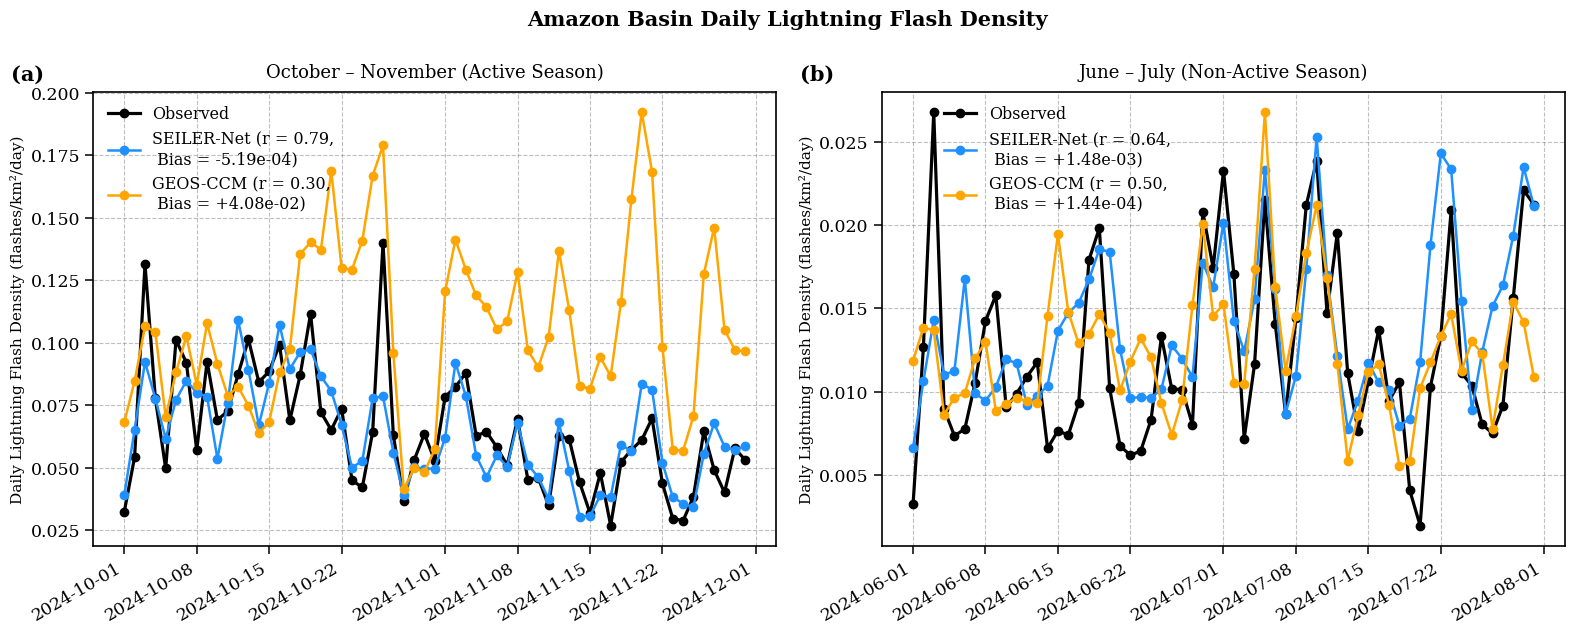

In [17]:
# ==============================================================================
# 1. CALCULATE DOMAIN AREA (km²) - PLACEHOLDERS: UPDATE WITH YOUR AMAZON BOUNDS
# ==============================================================================
R = 6371.0  # Earth's radius in km

lon1, lon2 = -67.0, -35.0
lat1, lat2 = -22.0, 10.0

# Convert degrees to radians for the spherical area formula
lon1_rad, lon2_rad = np.radians(lon1), np.radians(lon2)
lat1_rad, lat2_rad = np.radians(lat1), np.radians(lat2)

# Spherical bounding box area calculation
domain_area_km2 = (R**2) * (lon2_rad - lon1_rad) * (np.sin(lat2_rad) - np.sin(lat1_rad))


# ==============================================================================
# 2. DATA PROCESSING (AMAZON ON & AMAZON JJ)
# ==============================================================================

# --- [A] October - November (Amazon Active Season) ---
datetimes_ON = pd.to_datetime(glm_ON_ama["Datetime"].values)

# Model Predictions
model1_unlogged_ON = RegressionNoPrecip_ON_ama.sum(
    dim=("Latitudes", "Longitudes")
).squeeze()
daily_pred_model1_ON = (
    pd.Series(model1_unlogged_ON.values, index=datetimes_ON).resample("D").sum()
)

# Actual Observations
actual_unlogged_ON = glm_ON_ama.sum(dim=("Latitudes", "Longitudes")).squeeze()
daily_actual_ON = (
    pd.Series(actual_unlogged_ON.values, index=datetimes_ON).resample("D").sum()
)

# Lopez Observations
lopez_unlogged_ON = lopez_ON_ama.sum(dim=("Latitudes", "Longitudes")).squeeze()
daily_lopez_ON = (
    pd.Series(lopez_unlogged_ON.values, index=datetimes_ON).resample("D").sum()
)

# --- TURN ZERO-FLASH DAYS INTO NAN FOR CLEAN PLOT BREAKS ---
zero_days_ON = daily_actual_ON == 0
daily_actual_ON[zero_days_ON] = np.nan
daily_pred_model1_ON[zero_days_ON] = np.nan
daily_lopez_ON[zero_days_ON] = np.nan

# --- CONVERT FROM TOTAL FLASHES TO DENSITY (flashes/km²/day) ---
daily_actual_density_ON = daily_actual_ON / domain_area_km2
daily_pred_density_ON = daily_pred_model1_ON / domain_area_km2
daily_lopez_density_ON = daily_lopez_ON / domain_area_km2

# Metrics (pearsonr drops NaNs; pandas .mean() skips NaNs automatically)
r1_ON, _ = pearsonr(
    daily_pred_density_ON.dropna().values, daily_actual_density_ON.dropna().values
)
rlopez_ON, _ = pearsonr(
    daily_lopez_density_ON.dropna().values, daily_actual_density_ON.dropna().values
)
bias1_ON = (daily_pred_density_ON - daily_actual_density_ON).mean()
blopez_ON = (daily_lopez_density_ON - daily_actual_density_ON).mean()


# --- [B] June - July (Amazon Non-Active Season) ---
datetimes_JJ = pd.to_datetime(glm_JJ_ama["Datetime"].values)

# Model Predictions
model1_unlogged_JJ = RegressionNoPrecip_JJ_ama.sum(
    dim=("Latitudes", "Longitudes")
).squeeze()
daily_pred_model1_JJ = (
    pd.Series(model1_unlogged_JJ.values, index=datetimes_JJ).resample("D").sum()
)

# Actual Observations
actual_unlogged_JJ = glm_JJ_ama.sum(dim=("Latitudes", "Longitudes")).squeeze()
daily_actual_JJ = (
    pd.Series(actual_unlogged_JJ.values, index=datetimes_JJ).resample("D").sum()
)

# Lopez Observations
lopez_unlogged_JJ = lopez_JJ_ama.sum(dim=("Latitudes", "Longitudes")).squeeze()
daily_lopez_JJ = (
    pd.Series(lopez_unlogged_JJ.values, index=datetimes_JJ).resample("D").sum()
)

# --- TURN ZERO-FLASH DAYS INTO NAN FOR CLEAN PLOT BREAKS ---
zero_days_JJ = daily_actual_JJ == 0
daily_actual_JJ[zero_days_JJ] = np.nan
daily_pred_model1_JJ[zero_days_JJ] = np.nan
daily_lopez_JJ[zero_days_JJ] = np.nan

# --- CONVERT FROM TOTAL FLASHES TO DENSITY (flashes/km²/day) ---
daily_actual_density_JJ = daily_actual_JJ / domain_area_km2
daily_pred_density_JJ = daily_pred_model1_JJ / domain_area_km2
daily_lopez_density_JJ = daily_lopez_JJ / domain_area_km2

# Metrics (pearsonr drops NaNs; pandas .mean() skips NaNs automatically)
r1_JJ, _ = pearsonr(
    daily_pred_density_JJ.dropna().values, daily_actual_density_JJ.dropna().values
)
rlopez_JJ, _ = pearsonr(
    daily_lopez_density_JJ.dropna().values, daily_actual_density_JJ.dropna().values
)
bias1_JJ = (daily_pred_density_JJ - daily_actual_density_JJ).mean()
blopez_JJ = (daily_lopez_density_JJ - daily_actual_density_JJ).mean()


# ==============================================================================
# 3. PLOTTING THE MULTI-PANEL FIGURE
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), sharey=False)

# ------------------------------------------------------------------------------
# PANEL (a): Amazon October - November (Active)
# ------------------------------------------------------------------------------
ax1.plot(
    daily_actual_density_ON.index,
    daily_actual_density_ON.values,
    marker="o",
    linewidth=2.3,
    color="black",
    label="Observed",
)

ax1.plot(
    daily_pred_density_ON.index,
    daily_pred_density_ON.values,
    marker="o",
    linewidth=1.8,
    color="dodgerblue",
    label=f"SEILER-Net (r = {r1_ON:.2f},\n Bias = {bias1_ON:+.2e})",
)

ax1.plot(
    daily_lopez_density_ON.index,
    daily_lopez_density_ON.values,
    marker="o",
    linewidth=1.8,
    color="orange",
    label=f"GEOS-CCM (r = {rlopez_ON:.2f},\n Bias = {blopez_ON:+.2e})",
)

ax1.set_title("October – November (Active Season)", fontsize=13, pad=10)
ax1.set_ylabel("Daily Lightning Flash Density (flashes/km²/day)", fontsize=11)
ax1.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.0, 1.0), fontsize=11.5)

ax1.text(
    -0.12,
    1.06,
    "(a)",
    transform=ax1.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top",
)

# ------------------------------------------------------------------------------
# PANEL (b): Amazon June - July (Non-Active)
# ------------------------------------------------------------------------------
ax2.plot(
    daily_actual_density_JJ.index,
    daily_actual_density_JJ.values,
    marker="o",
    linewidth=2.3,
    color="black",
    label="Observed",
)

ax2.plot(
    daily_pred_density_JJ.index,
    daily_pred_density_JJ.values,
    marker="o",
    linewidth=1.8,
    color="dodgerblue",
    label=f"SEILER-Net (r = {r1_JJ:.2f}, \n Bias = {bias1_JJ:+.2e})",
)

ax2.plot(
    daily_lopez_density_JJ.index,
    daily_lopez_density_JJ.values,
    marker="o",
    linewidth=1.8,
    color="orange",
    label=f"GEOS-CCM (r = {rlopez_JJ:.2f}, \n Bias = {blopez_JJ:+.2e})",
)

ax2.set_title("June – July (Non-Active Season)", fontsize=13, pad=10)
ax2.set_ylabel("Daily Lightning Flash Density (flashes/km²/day)", fontsize=11)
ax2.legend(
    frameon=False, loc="upper left", bbox_to_anchor=(0.07, 1.0), fontsize=11.5
)

ax2.text(
    -0.12,
    1.06,
    "(b)",
    transform=ax2.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top",
)

# ==============================================================================
# 4. GLOBAL REFINEMENTS & FORMATTING
# ==============================================================================
for ax in [ax1, ax2]:
    ax.tick_params(axis="x", rotation=30, labelsize=12.5)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    # Set up scientific notation for the Y-axis to match script 1
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(-3, 3))
    ax.tick_params(axis="y", labelsize=12.5, direction="out")
    ax.grid(True, linestyle="--", alpha=0.5, color="gray")

    for spine in ax.spines.values():
        spine.set_visible(True)

# Main Figure Title
fig.suptitle(
    "Amazon Basin Daily Lightning Flash Density",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.savefig(
    "Amazon_Basin_Time_Series.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

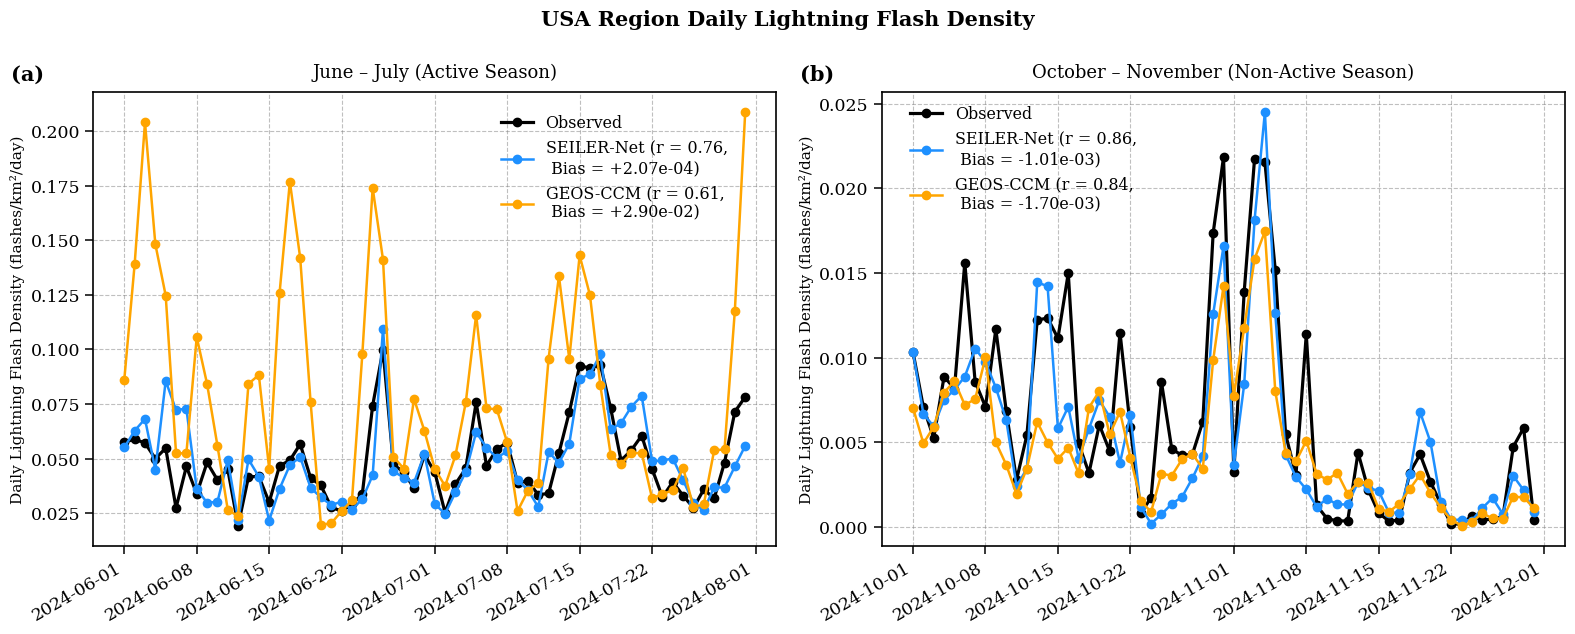

In [11]:
#USA Time Series, Seasonal

R = 6371.0  # Earth's radius in km

# TODO: Replace these placeholders with your actual USA domain coordinates
lon1, lon2 = -104.0, -72.0
lat1, lat2 = 18.0, 50.0

# Convert degrees to radians for the spherical area formula
lon1_rad, lon2_rad = np.radians(lon1), np.radians(lon2)
lat1_rad, lat2_rad = np.radians(lat1), np.radians(lat2)

# Spherical bounding box area calculation
domain_area_km2 = (R**2) * (lon2_rad - lon1_rad) * (np.sin(lat2_rad) - np.sin(lat1_rad))


# ==============================================================================
# 2. DATA PROCESSING (USA JJ & USA ON)
# ==============================================================================

# --- [A] June - July (USA Active Season) ---
datetimes_JJ = pd.to_datetime(glm_JJ["Datetime"].values)

# Model Predictions
model1_unlogged_JJ = RegressionNoPrecip_JJ.sum(
    dim=("Latitudes", "Longitudes")
).squeeze()
daily_pred_model1_JJ = (
    pd.Series(model1_unlogged_JJ.values, index=datetimes_JJ).resample("D").sum()
)

# Actual Observations
actual_unlogged_JJ = glm_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze()
daily_actual_JJ = (
    pd.Series(actual_unlogged_JJ.values, index=datetimes_JJ).resample("D").sum()
)

# Lopez Observations
lopez_unlogged_JJ = lopez_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze()
daily_lopez_JJ = (
    pd.Series(lopez_unlogged_JJ.values, index=datetimes_JJ).resample("D").sum()
)

# --- TURN ZERO-FLASH DAYS INTO NAN FOR CLEAN PLOT BREAKS ---
zero_days_JJ = daily_actual_JJ == 0
daily_actual_JJ[zero_days_JJ] = np.nan
daily_pred_model1_JJ[zero_days_JJ] = np.nan
daily_lopez_JJ[zero_days_JJ] = np.nan

# --- CONVERT FROM TOTAL FLASHES TO DENSITY (flashes/km²/day) ---
daily_actual_density_JJ = daily_actual_JJ / domain_area_km2
daily_pred_density_JJ = daily_pred_model1_JJ / domain_area_km2
daily_lopez_density_JJ = daily_lopez_JJ / domain_area_km2

# Metrics
r1_JJ, _ = pearsonr(
    daily_pred_density_JJ.dropna().values, daily_actual_density_JJ.dropna().values
)
rlopez_JJ, _ = pearsonr(
    daily_lopez_density_JJ.dropna().values, daily_actual_density_JJ.dropna().values
)
bias1_JJ = (daily_pred_density_JJ - daily_actual_density_JJ).mean()
blopez_JJ = (daily_lopez_density_JJ - daily_actual_density_JJ).mean()


# --- [B] October - November (USA Non-Active Season) ---
datetimes_ON = pd.to_datetime(glm_ON["Datetime"].values)

# Model Predictions
model1_unlogged_ON = RegressionNoPrecip_ON.sum(
    dim=("Latitudes", "Longitudes")
).squeeze()
daily_pred_model1_ON = (
    pd.Series(model1_unlogged_ON.values, index=datetimes_ON).resample("D").sum()
)

# Actual Observations
actual_unlogged_ON = glm_ON.sum(dim=("Latitudes", "Longitudes")).squeeze()
daily_actual_ON = (
    pd.Series(actual_unlogged_ON.values, index=datetimes_ON).resample("D").sum()
)

# Lopez Observations
lopez_unlogged_ON = lopez_ON.sum(dim=("Latitudes", "Longitudes")).squeeze()
daily_lopez_ON = (
    pd.Series(lopez_unlogged_ON.values, index=datetimes_ON).resample("D").sum()
)

# --- TURN ZERO-FLASH DAYS INTO NAN FOR CLEAN PLOT BREAKS ---
zero_days_ON = daily_actual_ON == 0
daily_actual_ON[zero_days_ON] = np.nan
daily_pred_model1_ON[zero_days_ON] = np.nan
daily_lopez_ON[zero_days_ON] = np.nan

# --- CONVERT FROM TOTAL FLASHES TO DENSITY (flashes/km²/day) ---
daily_actual_density_ON = daily_actual_ON / domain_area_km2
daily_pred_density_ON = daily_pred_model1_ON / domain_area_km2
daily_lopez_density_ON = daily_lopez_ON / domain_area_km2

# Metrics
r1_ON, _ = pearsonr(
    daily_pred_density_ON.dropna().values, daily_actual_density_ON.dropna().values
)
rlopez_ON, _ = pearsonr(
    daily_lopez_density_ON.dropna().values, daily_actual_density_ON.dropna().values
)
bias1_ON = (daily_pred_density_ON - daily_actual_density_ON).mean()
blopez_ON = (daily_lopez_density_ON - daily_actual_density_ON).mean()


# ==============================================================================
# 3. PLOTTING THE MULTI-PANEL FIGURE
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), sharey=False)

# ------------------------------------------------------------------------------
# PANEL (a): USA June - July (Active)
# ------------------------------------------------------------------------------
ax1.plot(
    daily_actual_density_JJ.index,
    daily_actual_density_JJ.values,
    marker="o",
    linewidth=2.3,
    color="black",
    label="Observed",
)

ax1.plot(
    daily_pred_density_JJ.index,
    daily_pred_density_JJ.values,
    marker="o",
    linewidth=1.8,
    color="dodgerblue",
    label=f"SEILER-Net (r = {r1_JJ:.2f},\n Bias = {bias1_JJ:+.2e})",
)

ax1.plot(
    daily_lopez_density_JJ.index,
    daily_lopez_density_JJ.values,
    marker="o",
    linewidth=1.8,
    color="orange",
    label=f"GEOS-CCM (r = {rlopez_JJ:.2f},\n Bias = {blopez_JJ:+.2e})",
)

ax1.set_title("June – July (Active Season)", fontsize=13, pad=10)
ax1.set_ylabel("Daily Lightning Flash Density (flashes/km²/day)", fontsize=11)

# FIXED: Shifted legend outside to the left of the plot to avoid data overlap
# Change this line under PANEL (a):
ax1.legend(
    frameon=False, 
    loc="upper right", 
    bbox_to_anchor=(0.95, 0.98), 
    fontsize=11.5
)

ax1.text(
    -0.12,
    1.06,
    "(a)",
    transform=ax1.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top",
)

# ------------------------------------------------------------------------------
# PANEL (b): USA October - November (Non-Active)
# ------------------------------------------------------------------------------
ax2.plot(
    daily_actual_density_ON.index,
    daily_actual_density_ON.values,
    marker="o",
    linewidth=2.3,
    color="black",
    label="Observed",
)

ax2.plot(
    daily_pred_density_ON.index,
    daily_pred_density_ON.values,
    marker="o",
    linewidth=1.8,
    color="dodgerblue",
    label=f"SEILER-Net (r = {r1_ON:.2f},\n Bias = {bias1_ON:+.2e})",
)

ax2.plot(
    daily_lopez_density_ON.index,
    daily_lopez_density_ON.values,
    marker="o",
    linewidth=1.8,
    color="orange",
    label=f"GEOS-CCM (r = {rlopez_ON:.2f},\n Bias = {blopez_ON:+.2e})",
)

ax2.set_title("October – November (Non-Active Season)", fontsize=13, pad=10)
ax2.set_ylabel("Daily Lightning Flash Density (flashes/km²/day)", fontsize=11)
ax2.legend(
    frameon=False, loc="upper left", bbox_to_anchor=(0.02, 1.0), fontsize=11.5
)

ax2.text(
    -0.12,
    1.06,
    "(b)",
    transform=ax2.transAxes,
    fontsize=15,
    fontweight="bold",
    va="top",
)

# ==============================================================================
# 4. GLOBAL REFINEMENTS & FORMATTING
# ==============================================================================
for ax in [ax1, ax2]:
    ax.tick_params(axis="x", rotation=30, labelsize=12.5)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(-3, 3))
    ax.tick_params(axis="y", labelsize=12.5, direction="out")
    ax.grid(True, linestyle="--", alpha=0.5, color="gray")

    for spine in ax.spines.values():
        spine.set_visible(True)

# Main Figure Title
fig.suptitle(
    "USA Region Daily Lightning Flash Density",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()
plt.savefig(
    "USA_Region_Lightning_Time_series.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)
plt.show()

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

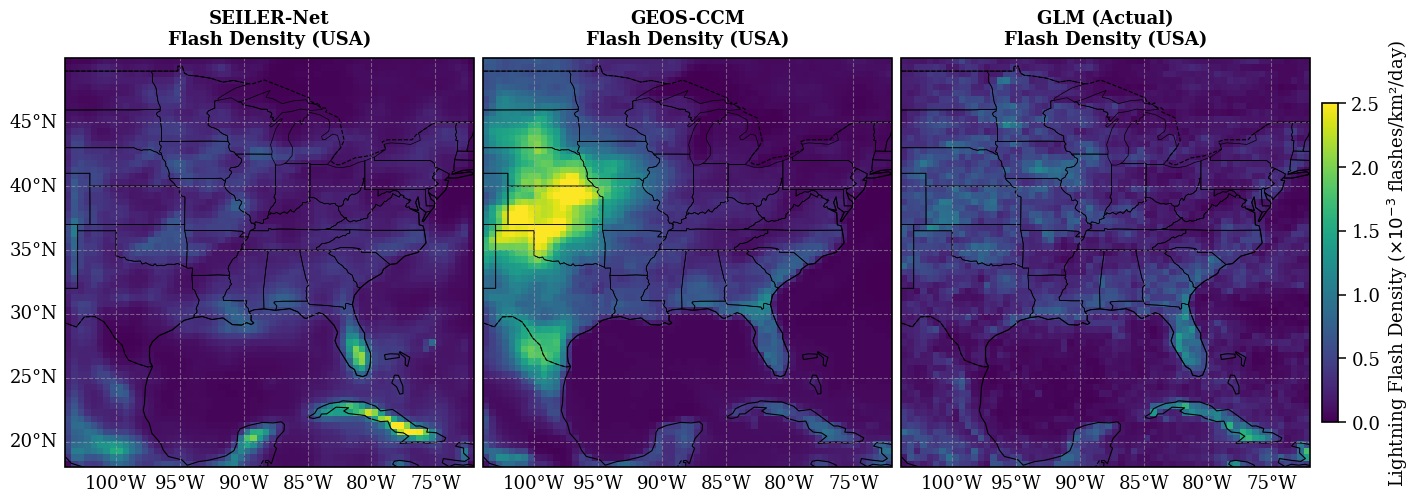

In [29]:
#Flash Density Plot
# ------------------------------------------------------------------------------
# 1. Setup Models and Reference (AMAZON DATASETS)
# ------------------------------------------------------------------------------
models = [model1_unlogged_usa, usa_Lopez_test, glm_usa]
model_names = ["SEILER-Net", "GEOS-CCM", "GLM (Actual)"]

# ------------------------------------------------------------------------------
# 2. Setup the Figure with Map Projection (1 Row, 3 Columns)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), subplot_kw={"projection": ccrs.PlateCarree()}
)

# Set the padding to zero for the constrained layout engine
fig.set_layout_engine(layout="constrained", w_pad=0.0, h_pad=0.0)

extent_amazon = [-79, -47, -22, 10]
extent_usa = [-104, -72, 18, 50]
vmax_val = 2.5  # Adjusted limit to bring out data variations
mesh = None  # Track the image object for the shared colorbar

# ------------------------------------------------------------------------------
# 3. Loop through and plot each model
# ------------------------------------------------------------------------------
for idx, (model_data, name, ax) in enumerate(zip(models, model_names, axes)):

    # --- 3a. Raw Sum Over Time ---
    raw_totals = model_data.sum(dim="Datetime").squeeze()
    num_days = len(model_data["Datetime"])

    # --- 3b. Mathematically Perfect Area Calculation ---
    lat_coords = model_data["Latitudes"].values
    lon_coords = model_data["Longitudes"].values

    dlat_rad = np.radians(abs(lat_coords[1] - lat_coords[0]))
    dlon_rad = np.radians(abs(lon_coords[1] - lon_coords[0]))
    R = 6371.0  # Earth's radius in km

    # Unique spherical area for each latitude strip
    lat_centers_rad = np.radians(lat_coords)
    cell_areas_km2 = (
        (R**2)
        * dlon_rad
        * (
            np.sin(lat_centers_rad + dlat_rad / 2)
            - np.sin(lat_centers_rad - dlat_rad / 2)
        )
    )

    # Broadcast to 2D grid shape
    grid_areas = cell_areas_km2[:, np.newaxis]

    # Convert raw sums to Flash Density: flashes / km² / day
    flash_density = (raw_totals.values / grid_areas) / num_days

    # --- 3c. Scale Data by 1000 for Visual Clarity ---
    flash_density_scaled = flash_density * 1000

    # Add Geographic Features to each map
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.8)
    ax.add_feature(
        cfeature.STATES.with_scale("110m"), linewidth=0.5, edgecolor="black"
    )
    ax.add_feature(
        cfeature.BORDERS.with_scale("110m"), linestyle="--", linewidth=0.8
    )

    ax.set_extent(extent_usa, crs=ccrs.PlateCarree())

    # Plot the scaled flash density data
    mesh = ax.imshow(
        flash_density_scaled,
        extent=extent_usa,
        origin="lower",
        cmap="viridis",
        vmin=0,
        vmax=vmax_val,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(
        f"{name}\nFlash Density (USA)", fontsize=13, fontweight="bold"
    )

    # Add gridlines to each map
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    # Only show latitude labels on the leftmost plot
    if idx > 0:
        gl.left_labels = False

    gl.xlabel_style = {"size": 13}
    gl.ylabel_style = {"size": 13}

# ------------------------------------------------------------------------------
# 4. Clean Shared Colorbar Placement
# ------------------------------------------------------------------------------
cbar = fig.colorbar(mesh, ax=axes, shrink=0.65, pad=0.01, location="right")

# Explicit steps from 0 up to 3 to keep ticks uniform
cbar.set_ticks([0, 0.5, 1, 1.5, 2, 2.5])

# Format as 1 decimal place ('%.1f') to fix duplicate label numbers
cbar.formatter = mticker.FormatStrFormatter("%.1f")
cbar.update_ticks()

# Standardized LaTeX scale description matching your spatial profiles
cbar.set_label(
    r"Lightning Flash Density ($\times 10^{-3}$ flashes/km²/day)", fontsize=13
)

# ------------------------------------------------------------------------------
# 5. Save and Export
# ------------------------------------------------------------------------------
plt.savefig(
    "USA_flash_density_comparison.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

This will be a time series of hourly flashes for each period. This will be for diurnal checks. 

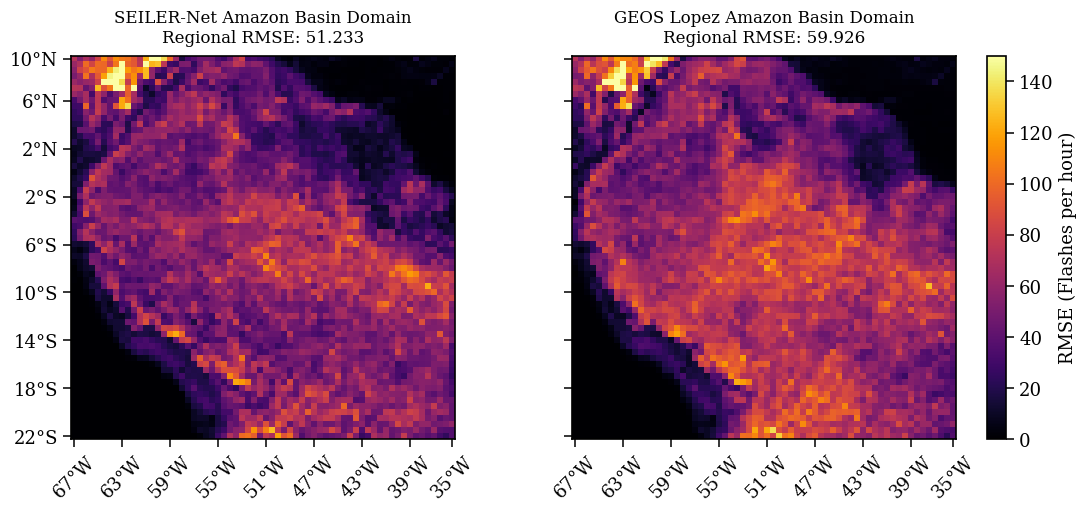

In [24]:
# import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1. Setup Models and Reference
# --------------------------------------------------
models = [
    model1_unlogged_amazon,
    amazon_Lopez_test
]
model_names = ["SEILER-Net", "GEOS Lopez"]
actual = glm_amazon.astype(np.float32)

# --------------------------------------------------
# 2. Plotting (With Constrained Layout)
# --------------------------------------------------
# layout="constrained" replaces tight_layout entirely and manages gaps cleanly
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True, layout="constrained")

#x_labels = ["104°W", "100°W", "96°W", "92°W", "88°W", "84°W", "80°W", "76°W", "72°W"]
#y_labels = ["18°N", "22°N", "26°N", "30°N", "34°N", "38°N", "42°N", "46°N", "50°N"]
x_labels = ["67°W", "63°W", "59°W", "55°W", "51°W", "47°W", "43°W", "39°W", "35°W"] 
y_labels = ["22°S", "18°S", "14°S", "10°S", "6°S", "2°S", "2°N", "6°N", "10°N"]
positions = [0, 8, 16, 24, 32, 40, 48, 56, 63]
vmax_val = 150  

# Keep track of the map for the colorbar
im = None

for idx, (model_data, name, ax) in enumerate(zip(models, model_names, axes)):
    
    # Compute Spatial RMSE
    model_cast = model_data.astype(np.float32)
    squared_error = (model_cast - actual)**2
    mean_squared_error = squared_error.mean(dim="Datetime")
    spatial_rmse_map = np.sqrt(mean_squared_error)
    
    global_rmse = np.sqrt(squared_error.mean().values)
    
    # Render map
    im = ax.imshow(
        spatial_rmse_map,
        origin="lower",
        cmap="inferno",
        vmax=vmax_val
    )
    
    ax.set_title(f"{name} Amazon Basin Domain\nRegional RMSE: {global_rmse:.3f}", fontsize=12)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(x_labels, rotation=45) 
    
    if idx == 0:
        ax.set_yticks(positions)
        ax.set_yticklabels(y_labels)
# 3. Clean Colorbar Placement
cbar = fig.colorbar(im, ax=axes, pad=0.01,location="right")
cbar.set_label("RMSE (Flashes per hour)", fontsize=13)

plt.savefig(
    "Amazon_spatial_RMSE.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

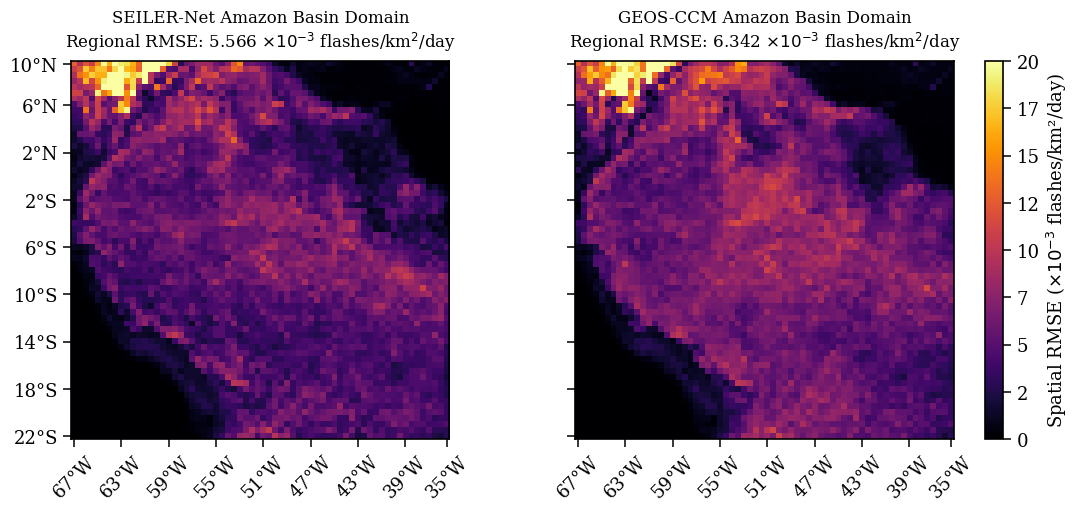

In [13]:
# ------------------------------------------------------------------------------
# 1. Setup Models and Reference (AMAZON DATASETS)
# ------------------------------------------------------------------------------
models = [model1_unlogged_amazon, amazon_Lopez_test]
model_names = ["SEILER-Net", "GEOS-CCM"]
actual = glm_amazon.astype(np.float32)

# ------------------------------------------------------------------------------
# 2. Plotting (With Constrained Layout)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(11, 5), sharey=True, layout="constrained"
)

x_labels = [
    "67°W",
    "63°W",
    "59°W",
    "55°W",
    "51°W",
    "47°W",
    "43°W",
    "39°W",
    "35°W",
]
#x_labels = [
#     "104°W",
#     "100°W",
#     "96°W",
#     "92°W",
#     "88°W",
#     "84°W",
#     "80°W",
#     "76°W",
#     "72°W",
# ]
y_labels = ["22°S", "18°S", "14°S", "10°S", "6°S", "2°S", "2°N", "6°N", "10°N"]
#y_labels = ["18°N", "22°N", "26°N", "30°N", "34°N", "38°N", "42°N", "46°N", "50°N"]

positions = [0, 8, 16, 24, 32, 40, 48, 56, 63]

# Adjust vmax_val down since data is now flash density scaled by 1000
vmax_val = 20.0

# Keep track of the map for the colorbar
im = None

# ------------------------------------------------------------------------------
# 3. Loop through and compute Spatial RMSE
# ------------------------------------------------------------------------------
for idx, (model_data, name, ax) in enumerate(zip(models, model_names, axes)):

    # --- 3a. Mathematically Perfect Area Calculation ---
    lat_coords = model_data["Latitudes"].values
    lon_coords = model_data["Longitudes"].values

    dlat_rad = np.radians(abs(lat_coords[1] - lat_coords[0]))
    dlon_rad = np.radians(abs(lon_coords[1] - lon_coords[0]))
    R = 6371.0  # Earth's radius in km

    # Unique spherical area for each latitude strip
    lat_centers_rad = np.radians(lat_coords)
    cell_areas_km2 = (
        (R**2)
        * dlon_rad
        * (
            np.sin(lat_centers_rad + dlat_rad / 2)
            - np.sin(lat_centers_rad - dlat_rad / 2)
        )
    )

    # Broadcast to an xarray DataArray that mirrors the grid's dimensions
    grid_areas = model_data["Latitudes"] * 0 + cell_areas_km2

    # --- 3b. Convert BOTH arrays to Density and Scale by 1000 ---
    model_density_scaled = (model_data / grid_areas) * 1000
    actual_density_scaled = (actual / grid_areas) * 1000

    # --- 3c. Calculate Spatial Grid RMSE using xarray math ---
    squared_error = (model_density_scaled - actual_density_scaled) ** 2

    # Mean over the Datetime dimension
    mean_squared_error = squared_error.mean(dim="Datetime")
    spatial_rmse_map = np.sqrt(mean_squared_error.values)

    # Calculate a single global domain RMSE score for the title
    global_rmse = np.sqrt(squared_error.mean().values)

    # --- 3d. Render Map ---
    im = ax.imshow(
        spatial_rmse_map, origin="lower", cmap="inferno", vmax=vmax_val
    )

    ax.set_title(
        f"{name} Amazon Basin Domain\nRegional RMSE: {global_rmse:.3f} " + r"$\times 10^{-3}$ flashes/km$^2$/day",
        fontsize=12,
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(x_labels, rotation=45)

    if idx == 0:
        ax.set_yticks(positions)
        ax.set_yticklabels(y_labels)

# ------------------------------------------------------------------------------
# 4. Clean Colorbar Placement
# ------------------------------------------------------------------------------
cbar = fig.colorbar(im, ax=axes, pad=0.01, location="right")

# Keep colorbar ticks as clean integers
cbar.formatter = mticker.FormatStrFormatter("%d")
cbar.update_ticks()

cbar.set_label(
    r"Spatial RMSE ($\times 10^{-3}$ flashes/km²/day)", fontsize=13
)

plt.savefig(
    "Amazon_spatial_RMSE.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

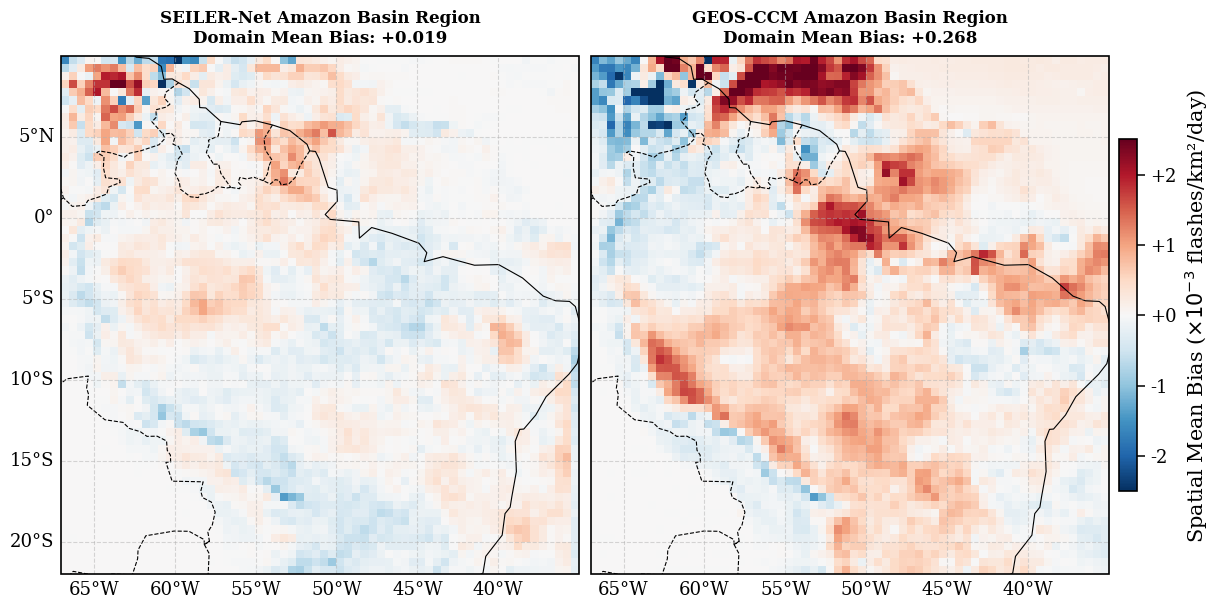

In [37]:
#Bias Plots
models = [
    model1_unlogged_amazon,
    amazon_Lopez_test
]
model_names = ["SEILER-Net", "GEOS-CCM"]

# Explicitly isolate the actual reference array
actual_data = glm_amazon

# ==============================================================================
# 2. SETUP THE MULTI-PANEL GRID (1 Row, 2 Columns)
# ==============================================================================
fig, axes = plt.subplots(
    1, 2, 
    figsize=(12, 6), 
    subplot_kw={'projection': ccrs.PlateCarree()}
)

fig.set_layout_engine(layout="constrained", w_pad=0.0, h_pad=0.0)

extent_africa = [-67, -35, -22, 10]

# Symmetric max limit around zero so that White means exactly a 0 bias
vmax_val = 2.5  
im = None

# ==============================================================================
# 3. LOOP THROUGH AND COMPUTE SPATIAL BIAS
# ==============================================================================
for idx, (model_data, name, ax) in enumerate(zip(models, model_names, axes)):
    
    # --- 3a. Extract Lat/Lon Dimensions and calculate spherical grid cell areas ---
    lat_coords = model_data["Latitudes"].values
    lon_coords = model_data["Longitudes"].values
    
    dlat_rad = np.radians(abs(lat_coords[1] - lat_coords[0]))
    dlon_rad = np.radians(abs(lon_coords[1] - lon_coords[0]))
    R = 6371.0  
    
    lat_centers_rad = np.radians(lat_coords)
    cell_areas_km2 = (R**2) * dlon_rad * (
        np.sin(lat_centers_rad + dlat_rad / 2) - np.sin(lat_centers_rad - dlat_rad / 2)
    )
    
    # Keep grid_areas as an xarray DataArray so it seamlessly aligns with the models
    grid_areas = model_data["Latitudes"] * 0 + cell_areas_km2
    
    # --- 3b. Convert BOTH arrays using xarray native math (Auto-aligns dimensions) ---
    model_density_scaled = (model_data / grid_areas) * 1000
    actual_density_scaled = (actual_data / grid_areas) * 1000
    
    # --- 3c. Calculate Mean Spatial Bias over time ---
    spatial_bias_map = (model_density_scaled - actual_density_scaled).mean(dim="Datetime")
    
    # Calculate a single global domain-wide mean bias score for the title
    global_bias = (model_density_scaled - actual_density_scaled).mean().values
    
    # --- 3d. Add Geographic Maps Elements ---
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth=0.8)
    ax.add_feature(cfeature.STATES.with_scale('110m'), linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.BORDERS.with_scale('110m'), linestyle='--', linewidth=0.8)
    
    ax.set_extent(extent_africa, crs=ccrs.PlateCarree())
    
    # --- 3e. Display Bias Map ---
    # RdBu_r uses Blue for negative numbers (underestimation) and Red for positive (overestimation)
    im = ax.imshow(
        spatial_bias_map.values,  
        extent=extent_africa,
        origin="lower",
        cmap="RdBu_r",  
        vmin=-vmax_val, # Symmetric boundaries are required to center 0 at pure white
        vmax=vmax_val,
        transform=ccrs.PlateCarree()
    )
    
    # The :+.3f adds a persistent explicit + or - to the domain-wide metric string
    ax.set_title(f"{name} Amazon Basin Region\nDomain Mean Bias: {global_bias:+.3f}", fontsize=12, fontweight='bold')
    
    # --- 3f. Configure Gridlines ---
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    if idx > 0:
        gl.left_labels = False
        
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}

# ==============================================================================
# 4. COLORBAR AND EXPORT
# ==============================================================================
cbar = fig.colorbar(im, ax=axes, shrink=0.6, pad=0.01, location="right")

# Format ticks to explicitly display sign changes (+3, +2, +1, 0, -1, -2, -3)
cbar.formatter = mticker.FormatStrFormatter('%+d')
cbar.update_ticks()

cbar.set_label(r"Spatial Mean Bias ($\times 10^{-3}$ flashes/km²/day)", fontsize=15)

#Save PDF to disk
plt.savefig(
    "Amazon_spatial_Bias.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

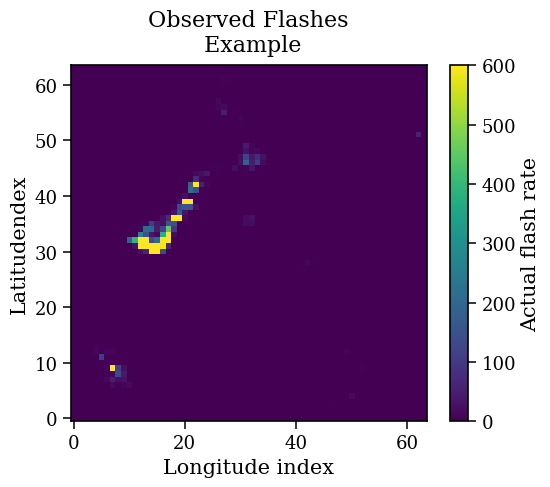

In [38]:
# Choose a single sample, e.g., the first datetime
sample = glm_usa.squeeze().isel(Datetime=100)  # select first time step

plt.figure(figsize=(6,5))
im = plt.imshow(sample, origin="lower", vmin=0, vmax=600)  # fix color scale if you like
plt.colorbar(im, label="Actual flash rate")
plt.title(f"Observed Flashes\n Example")
plt.xlabel("Longitude index")
plt.ylabel("Latitudendex")
plt.tight_layout()
plt.show()


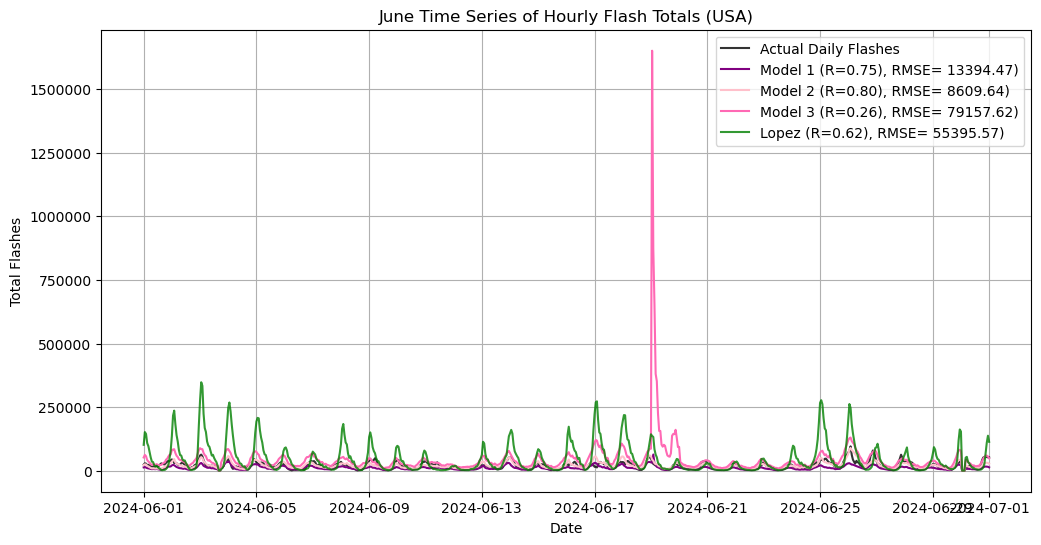

In [28]:
#Change the data to accomadate USA or Amazon. JJ or ON

# --- same up to your 'series' ---
datetimes = pd.to_datetime(actual_JJ['Datetime'].values)

pred_model1 = model1_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze() 
pred_model2 = model2_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze() 
pred_model3 = model3_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze() 
pred_model4 = model4_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze() 
pred_model5 = model5_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze() 
pred_model6 = model6_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze() 
lopez = lopez_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze() 
actual_flashesUNlogged = actual_JJ.sum(dim=("Latitudes", "Longitudes")).squeeze() 

series1 = pd.Series(pred_model1, index=datetimes)
series2 = pd.Series(pred_model2, index=datetimes)
series3 = pd.Series(pred_model3, index=datetimes)
series4 = pd.Series(pred_model4, index=datetimes)
series5 = pd.Series(pred_model5, index=datetimes)
series6 = pd.Series(pred_model6, index=datetimes)
series_lopez = pd.Series(lopez, index=datetimes)
actual_series = pd.Series(actual_flashesUNlogged, index=datetimes)

# --- NEW: keep only the first 3 days ---
#start_date = series.index.min()
start_date = pd.Timestamp("2024-06-01 00:00:00") 
end_date = start_date + pd.Timedelta(days=30)
series_model1 = series1.loc[start_date:end_date]
series_model2 = series2.loc[start_date:end_date]
series_model3 = series3.loc[start_date:end_date]

series_lopez = series_lopez.loc[start_date:end_date]
actualseries_day = actual_series.loc[start_date:end_date]

# --- Resample to hourly totals ---
hourly_flashes1 = series_model1.resample("h").sum()
hourly_flashes2 = series_model2.resample("h").sum()
hourly_flashes3 = series_model3.resample("h").sum()
hourly_lopez = series_lopez.resample("h").sum()
actualhourly_flashes = actualseries_day.resample("h").sum()


#Pearson R:
corr1 = hourly_flashes1.corr(actualhourly_flashes)
corr2 = hourly_flashes2.corr(actualhourly_flashes)
corr3 = hourly_flashes3.corr(actualhourly_flashes)
corr_lopez = hourly_lopez.corr(actualhourly_flashes)

from sklearn.metrics import mean_squared_error
rmse1 = np.sqrt(mean_squared_error(actualhourly_flashes, hourly_flashes1))
rmse2 = np.sqrt(mean_squared_error(actualhourly_flashes, hourly_flashes2))
rmse3 = np.sqrt(mean_squared_error(actualhourly_flashes, hourly_flashes3))
rmse_lopez = np.sqrt(mean_squared_error(actualhourly_flashes, hourly_lopez))


# --- Plot together ---
plt.figure(figsize=(12,6))
plt.plot(actualhourly_flashes.index, actualhourly_flashes.values, color="black", alpha = 0.8, label="Actual Daily Flashes")
plt.plot(hourly_flashes1.index, hourly_flashes1.values, color="purple", label=f"Model 1 (R={corr1:.2f}), RMSE={rmse1: .2f})")
plt.plot(hourly_flashes2.index, hourly_flashes2.values, color="pink",label=f"Model 2 (R={corr2:.2f}), RMSE={rmse2: .2f})")
plt.plot(hourly_flashes3.index, hourly_flashes3.values, color="hotpink",label=f"Model 3 (R={corr3:.2f}), RMSE={rmse3: .2f})")
plt.plot(hourly_lopez.index, hourly_lopez.values, color="green", alpha = 0.8, label=f"Lopez (R={corr_lopez:.2f}), RMSE={rmse_lopez: .2f})")

plt.xlabel("Date")
plt.ylabel("Total Flashes")
plt.title("June Time Series of Hourly Flash Totals (USA)")
plt.grid()
plt.legend()
# --- Force y-axis to show full numbers ---
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")
plt.show()


Now, I want to start looking at the difference between Land and Ocean. 

In [39]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 50,             # Global baseline size (up from 12)
    'axes.labelsize': 18,        # X and Y axis labels (up from 14)
    'axes.titlesize': 20,        # Individual plot titles (up from 16)
    'xtick.labelsize': 18,       # X axis tick numbers (up from 11)
    'ytick.labelsize': 18,       # Y axis tick numbers (up from 11)
    'legend.fontsize': 14,       # Legend text inside the box (up from 11)
    'lines.linewidth': 2.5,      # Bumping up line thickness slightly to match the text weight
    'lines.markersize': 7,       # Bumping up marker dots slightly
    'axes.facecolor': 'white',   
    'figure.facecolor': 'white'
})

In [40]:
# 1. Create copies with actual longitude values for the USA
glm_local_prep_JJ = glm_JJ.squeeze().assign_coords(Longitudes=np.linspace(-104, -72, 64))
glm_local_prep_ON = glm_ON.squeeze().assign_coords(Longitudes=np.linspace(-104, -72, 64))

lopez_local_prep_JJ = lopez_JJ.assign_coords(Longitudes=np.linspace(-104, -72, 64))
lopez_local_prep_ON = lopez_ON.assign_coords(Longitudes=np.linspace(-104, -72, 64))

regression_local_prep_JJ = RegressionNoPrecip_JJ.assign_coords(Longitudes=np.linspace(-104, -72, 64))
regression_local_prep_ON = RegressionNoPrecip_ON.assign_coords(Longitudes=np.linspace(-104, -72, 64))

# Verify shapes
print("JJ Shapes -> GLM:", glm_local_prep_JJ.shape, "Lopez:", lopez_local_prep_JJ.shape, "SEILER:", regression_local_prep_JJ.shape)
print("ON Shapes -> GLM:", glm_local_prep_ON.shape, "Lopez:", lopez_local_prep_ON.shape, "SEILER:", regression_local_prep_ON.shape)

# 2. Define models and colors once
local_models_JJ = {"SEILER-Net": regression_local_prep_JJ, "GEOS-CCM": lopez_local_prep_JJ, "GLM": glm_local_prep_JJ}
local_models_ON = {"SEILER-Net": regression_local_prep_ON, "GEOS-CCM": lopez_local_prep_ON, "GLM": glm_local_prep_ON}

colors = {"SEILER-Net": "dodgerblue", "GEOS-CCM": "orange", "GLM": "black"}

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'lines.linewidth': 2, 'lines.markersize': 6, 'axes.facecolor': 'white', 'figure.facecolor': 'white'
})

# 3. Calculate offsets (They are the same for both since longitudes match)
lon_offsets = np.round(local_models_JJ["GLM"]["Longitudes"].values / 15).astype(int)
# 4. Populate JJ dictionary
local_shifted_models_JJ = {}
for name, da in local_models_JJ.items():
    time_hours = pd.to_datetime(da["Datetime"].values).hour.values
    local_hours_2d = (time_hours[:, np.newaxis] + lon_offsets[np.newaxis, :]) % 24
    local_shifted_models_JJ[name] = {"values": da.values, "local_hours": local_hours_2d}

# 5. Populate ON dictionary
local_shifted_models_ON = {}
for name, da in local_models_ON.items():
    time_hours = pd.to_datetime(da["Datetime"].values).hour.values
    local_hours_2d = (time_hours[:, np.newaxis] + lon_offsets[np.newaxis, :]) % 24
    local_shifted_models_ON[name] = {"values": da.values, "local_hours": local_hours_2d}

JJ Shapes -> GLM: (1455, 64, 64) Lopez: (1455, 64, 64) SEILER: (1455, 64, 64)
ON Shapes -> GLM: (1427, 64, 64) Lopez: (1427, 64, 64) SEILER: (1427, 64, 64)


In [41]:
# 1. Create copies with actual longitude values for the AMAZON
glm_local_prep_JJ_ama = glm_JJ_ama.squeeze().assign_coords(Longitudes=np.linspace(-67, -35, 64))
glm_local_prep_ON_ama = glm_ON_ama.squeeze().assign_coords(Longitudes=np.linspace(-67, -35, 64))

lopez_local_prep_JJ_ama = lopez_JJ_ama.assign_coords(Longitudes=np.linspace(-67, -35, 64))
lopez_local_prep_ON_ama = lopez_ON_ama.assign_coords(Longitudes=np.linspace(-67, -35, 64))

regression_local_prep_JJ_ama = RegressionNoPrecip_JJ_ama.assign_coords(Longitudes=np.linspace(-67, -35, 64))
regression_local_prep_ON_ama = RegressionNoPrecip_ON_ama.assign_coords(Longitudes=np.linspace(-67, -35, 64))

# Verify shapes
print("JJ Shapes -> GLM:", glm_local_prep_JJ_ama.shape, "Lopez:", lopez_local_prep_JJ_ama.shape, "SEILER:", regression_local_prep_JJ_ama.shape)
print("ON Shapes -> GLM:", glm_local_prep_ON_ama.shape, "Lopez:", lopez_local_prep_ON_ama.shape, "SEILER:", regression_local_prep_ON_ama.shape)

# 2. Define models and colors once
local_models_JJ_ama = {"SEILER-Net": regression_local_prep_JJ_ama, "GEOS-CCM": lopez_local_prep_JJ_ama, "GLM": glm_local_prep_JJ_ama}
local_models_ON_ama = {"SEILER-Net": regression_local_prep_ON_ama, "GEOS-CCM": lopez_local_prep_ON_ama, "GLM": glm_local_prep_ON_ama}

colors = {"SEILER-Net": "dodgerblue", "GEOS-CCM": "orange", "GLM": "black"}

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'lines.linewidth': 2, 'lines.markersize': 6, 'axes.facecolor': 'white', 'figure.facecolor': 'white'
})

lon_offsets_float = local_models_JJ_ama["GLM"]["Longitudes"].values / 15

# 2. Populate JJ dictionary with high-resolution rounding
local_shifted_models_JJ_ama = {}
for name, da in local_models_JJ_ama.items():
    time_hours = pd.to_datetime(da["Datetime"].values).hour.values
    
    # Calculate exact local hours as floats, then round the FINAL result to the nearest hour
    exact_local_hours = time_hours[:, np.newaxis] + lon_offsets_float[np.newaxis, :]
    local_hours_2d = np.round(exact_local_hours).astype(int) % 24
    
    local_shifted_models_JJ_ama[name] = {"values": da.values, "local_hours": local_hours_2d}

# 3. Populate ON dictionary with high-resolution rounding
local_shifted_models_ON_ama = {}
for name, da in local_models_ON_ama.items():
    time_hours = pd.to_datetime(da["Datetime"].values).hour.values
    
    # Exact calculation + final rounding
    exact_local_hours = time_hours[:, np.newaxis] + lon_offsets_float[np.newaxis, :]
    local_hours_2d = np.round(exact_local_hours).astype(int) % 24
    
    local_shifted_models_ON_ama[name] = {"values": da.values, "local_hours": local_hours_2d}

JJ Shapes -> GLM: (1455, 64, 64) Lopez: (1455, 64, 64) SEILER: (1455, 64, 64)
ON Shapes -> GLM: (1458, 64, 64) Lopez: (1458, 64, 64) SEILER: (1458, 64, 64)


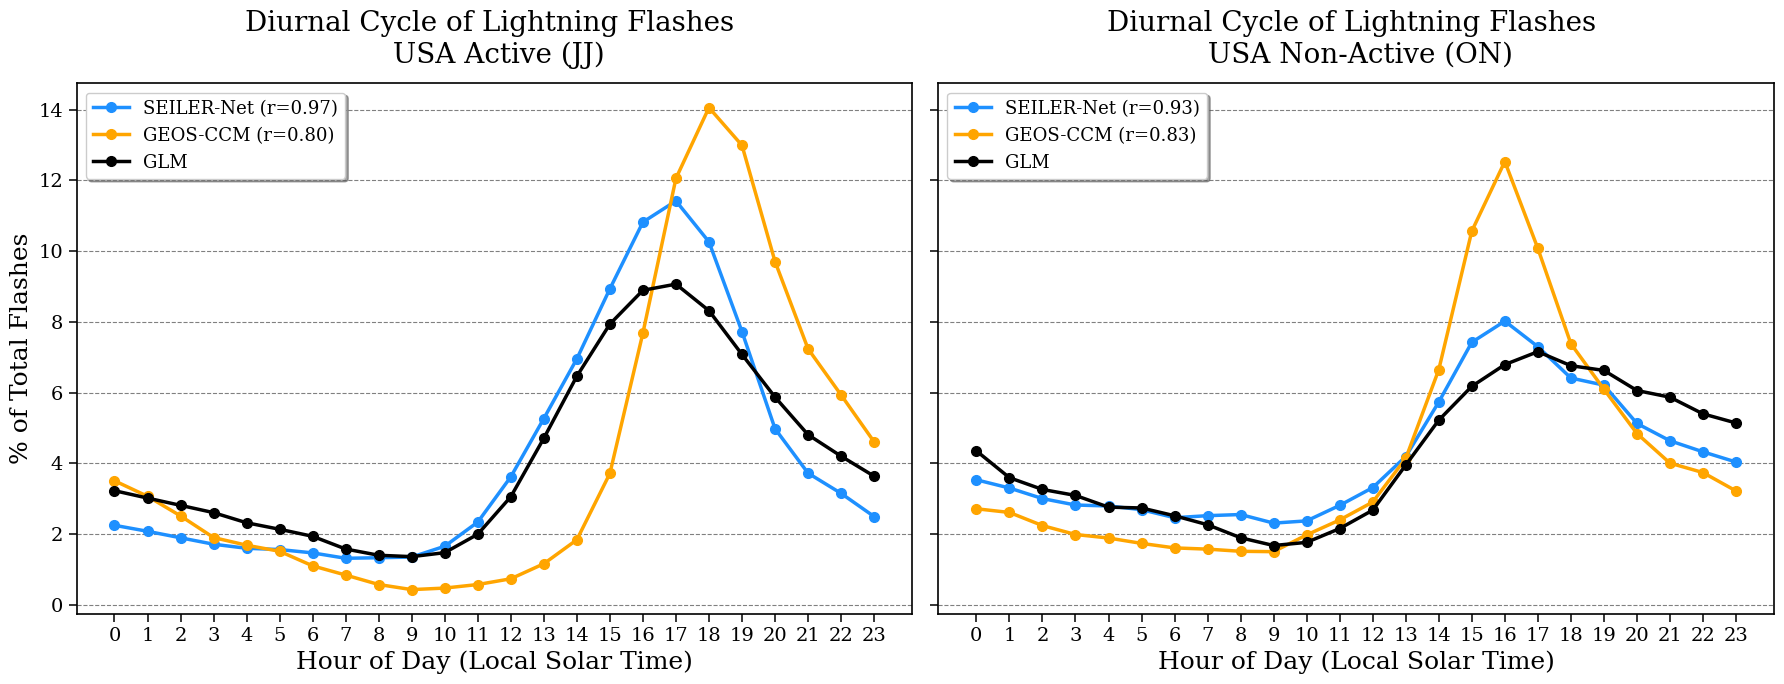

In [22]:
# 1. Compute Reference (GLM) local diurnal cycle for JJ
ref_series_JJ = np.zeros(24)
glm_v_JJ = local_shifted_models_JJ["GLM"]["values"]
glm_hours_3d_JJ = np.broadcast_to(local_shifted_models_JJ["GLM"]["local_hours"][:, np.newaxis, :], glm_v_JJ.shape)

for hour in range(24):
    ref_series_JJ[hour] = glm_v_JJ[glm_hours_3d_JJ == hour].sum()
ref_percent_JJ = 100 * ref_series_JJ / ref_series_JJ.sum()

# 2. Compute Reference (GLM) local diurnal cycle for ON
ref_series_ON = np.zeros(24)
glm_v_ON = local_shifted_models_ON["GLM"]["values"]
glm_hours_3d_ON = np.broadcast_to(local_shifted_models_ON["GLM"]["local_hours"][:, np.newaxis, :], glm_v_ON.shape)

for hour in range(24):
    ref_series_ON[hour] = glm_v_ON[glm_hours_3d_ON == hour].sum()
ref_percent_ON = 100 * ref_series_ON / ref_series_ON.sum()


# 3. Set up the side-by-side figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)


# === LEFT PLOT: Active Period (JJ) ===
for name, data in local_shifted_models_JJ.items():
    hourly_series = np.zeros(24)
    v = data["values"]
    hours_3d = np.broadcast_to(data["local_hours"][:, np.newaxis, :], v.shape)
    
    for hour in range(24):
        hourly_series[hour] = v[hours_3d == hour].sum()
        
    percent_diurnal = 100 * hourly_series / hourly_series.sum()

    if name != "GLM":
        corr = np.corrcoef(percent_diurnal, ref_percent_JJ)[0, 1]
        label = f"{name} (r={corr:.2f})"
    else:
        label = name

    # Bumped up linewidth to 2.5 and markersize to 7
    ax1.plot(range(0, 24), percent_diurnal, marker='o', linewidth=2.5, markersize=7, color=colors[name], label=label)

# FORCED FONT SIZES HERE
ax1.set_xlabel("Hour of Day (Local Solar Time)", fontsize=18, fontfamily='serif')
ax1.set_ylabel("% of Total Flashes", fontsize=18, fontfamily='serif')
ax1.set_title("Diurnal Cycle of Lightning Flashes \n USA Active (JJ)", fontsize=20, fontfamily='serif', pad=15)
ax1.set_xticks(range(0, 24))
ax1.tick_params(axis='both', labelsize=14) # Forces tick numbers to 14
ax1.grid(axis='y', linestyle='--', alpha=1.0, color="gray")
ax1.legend(loc='upper left', frameon=True, shadow=True, fontsize=13)


# === RIGHT PLOT: Non-Active Period (ON) ===
for name, data in local_shifted_models_ON.items():
    hourly_series = np.zeros(24)
    v = data["values"]
    hours_3d = np.broadcast_to(data["local_hours"][:, np.newaxis, :], v.shape)
    
    for hour in range(24):
        hourly_series[hour] = v[hours_3d == hour].sum()
        
    percent_diurnal = 100 * hourly_series / hourly_series.sum()

    if name != "GLM":
        corr = np.corrcoef(percent_diurnal, ref_percent_ON)[0, 1]
        label = f"{name} (r={corr:.2f})"
    else:
        label = name

    # Bumped up linewidth to 2.5 and markersize to 7
    ax2.plot(range(0, 24), percent_diurnal, marker='o', linewidth=2.5, markersize=7, color=colors[name], label=label)

# FORCED FONT SIZES HERE
ax2.set_xlabel("Hour of Day (Local Solar Time)", fontsize=18, fontfamily='serif')
ax2.set_title("Diurnal Cycle of Lightning Flashes \n USA Non-Active (ON)", fontsize=20, fontfamily='serif', pad=15)
ax2.set_xticks(range(0, 24))
ax2.tick_params(axis='both', labelsize=14) # Forces tick numbers to 14
ax2.grid(axis='y', linestyle='--', alpha=1.0, color="gray")
ax2.legend(loc='upper left', frameon=True, shadow=True, fontsize=13)

plt.tight_layout()

# Save the figure with high quality (300 DPI is standard for publications)
bbox_inches="tight" #ensures none of your new larger labels get clipped off
plt.savefig("lightning_diurnal_cycles-USA.pdf", dpi=300, bbox_inches="tight")
plt.show()
# Always a good practice to close the figure afterwards to free up memory
plt.close()


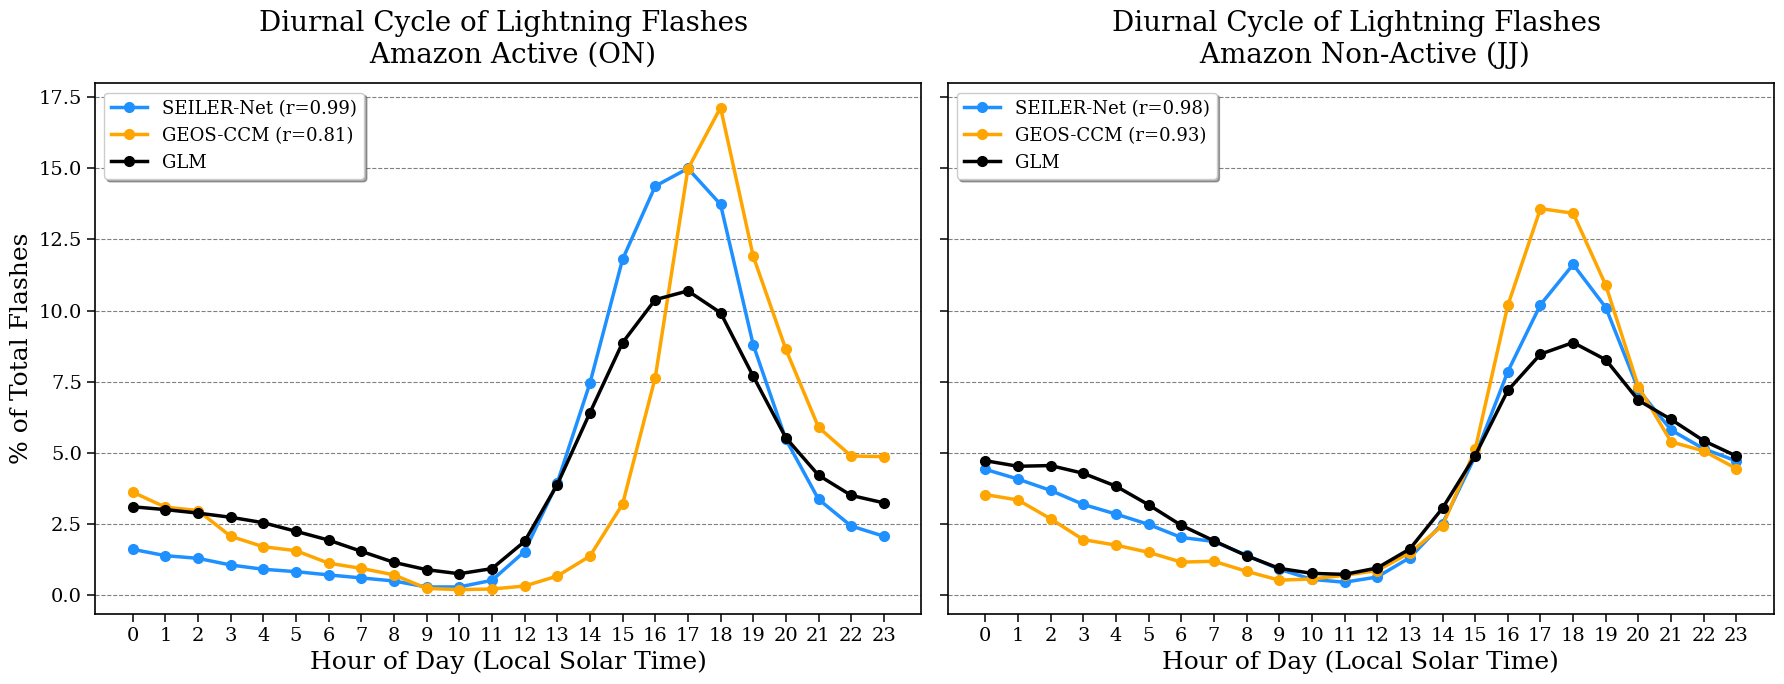

In [23]:
# 1. Compute Reference (GLM) local diurnal cycle for ON (Active Season)
ref_series_ON_ama = np.zeros(24)
glm_v_ON_ama = local_shifted_models_ON_ama["GLM"]["values"]
glm_hours_3d_ON_ama = np.broadcast_to(local_shifted_models_ON_ama["GLM"]["local_hours"][:, np.newaxis, :], glm_v_ON_ama.shape)

for hour in range(24):
    ref_series_ON_ama[hour] = glm_v_ON_ama[glm_hours_3d_ON_ama == hour].sum()
ref_percent_ON_ama = 100 * ref_series_ON_ama / ref_series_ON_ama.sum()

# 2. Compute Reference (GLM) local diurnal cycle for JJ (Non-Active Season)
ref_series_JJ_ama = np.zeros(24)
glm_v_JJ_ama = local_shifted_models_JJ_ama["GLM"]["values"]
glm_hours_3d_JJ_ama = np.broadcast_to(local_shifted_models_JJ_ama["GLM"]["local_hours"][:, np.newaxis, :], glm_v_JJ_ama.shape)

for hour in range(24):
    ref_series_JJ_ama[hour] = glm_v_JJ_ama[glm_hours_3d_JJ_ama == hour].sum()
ref_percent_JJ_ama = 100 * ref_series_JJ_ama / ref_series_JJ_ama.sum()


# 3. Set up the side-by-side figure (Active on Left, Non-Active on Right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)


# === LEFT PLOT: Active Period (ON) ===
for name, data in local_shifted_models_ON_ama.items():
    hourly_series = np.zeros(24)
    v = data["values"]
    hours_3d = np.broadcast_to(data["local_hours"][:, np.newaxis, :], v.shape)
    
    for hour in range(24):
        hourly_series[hour] = v[hours_3d == hour].sum()
        
    percent_diurnal = 100 * hourly_series / hourly_series.sum()

    if name != "GLM":
        corr = np.corrcoef(percent_diurnal, ref_percent_ON_ama)[0, 1]
        label = f"{name} (r={corr:.2f})"
    else:
        label = name

    ax1.plot(range(0, 24), percent_diurnal, marker='o', linewidth=2.5, markersize=7, color=colors[name], label=label)

ax1.set_xlabel("Hour of Day (Local Solar Time)", fontsize=18, fontfamily='serif')
ax1.set_ylabel("% of Total Flashes", fontsize=18, fontfamily='serif')
ax1.set_title("Diurnal Cycle of Lightning Flashes \n Amazon Active (ON)", fontsize=20, fontfamily='serif', pad=15)
ax1.set_xticks(range(0, 24))
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(axis='y', linestyle='--', alpha=1.0, color="gray")
ax1.legend(loc='upper left', frameon=True, shadow=True, fontsize=13)


# === RIGHT PLOT: Non-Active Period (JJ) ===
for name, data in local_shifted_models_JJ_ama.items():
    hourly_series = np.zeros(24)
    v = data["values"]
    hours_3d = np.broadcast_to(data["local_hours"][:, np.newaxis, :], v.shape)
    
    for hour in range(24):
        hourly_series[hour] = v[hours_3d == hour].sum()
        
    percent_diurnal = 100 * hourly_series / hourly_series.sum()

    if name != "GLM":
        corr = np.corrcoef(percent_diurnal, ref_percent_JJ_ama)[0, 1]
        label = f"{name} (r={corr:.2f})"
    else:
        label = name

    ax2.plot(range(0, 24), percent_diurnal, marker='o', linewidth=2.5, markersize=7, color=colors[name], label=label)

ax2.set_xlabel("Hour of Day (Local Solar Time)", fontsize=18, fontfamily='serif')
ax2.set_title("Diurnal Cycle of Lightning Flashes \n Amazon Non-Active (JJ)", fontsize=20, fontfamily='serif', pad=15)
ax2.set_xticks(range(0, 24))
ax2.tick_params(axis='both', labelsize=14)
ax2.grid(axis='y', linestyle='--', alpha=1.0, color="gray")
ax2.legend(loc='upper left', frameon=True, shadow=True, fontsize=13)


plt.tight_layout()

# Save vector PDF first, then show it
plt.savefig("amazon_lightning_diurnal_cycles.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
#Land Ocean Evaluation
#I need to get all the land grid cells from the USA in their own array. I need to do the same for the ocean. 
#Step 1. Take in the LWI data. 
USA_LWI = xr.open_dataset("testing_LWI_us.nc")
usa_lwi = USA_LWI['lwi']
Amazon_LWI = xr.open_dataset("testing_LWI_amazon.nc")
amazon_lwi = Amazon_LWI['lwi']

In [43]:
#Separating the Data: 
# land/ocean flag
flag = usa_lwi  # DataArray (Latitudes, Longitudes)
flag_ama = amazon_lwi
# Create boolean masks
land_mask  = flag >= 0.55
water_mask = flag < 0.55
land_mask_a  = flag_ama >= 0.55
water_mask_a = flag_ama < 0.55

In [44]:
#Density Scatter Plots for Ocean and Land 
# List of models for prediction
models_JJ = [
    RegressionNoPrecip_JJ,
    lopez_JJ, glm_JJ.squeeze()  # include Lopez & GLM
]
models_ON = [
    RegressionNoPrecip_ON,
    lopez_ON, glm_ON.squeeze()  # include Lopez & GLM
]

# Apply masks to create separate la"nd and ocean datasets
models_land_JJ = [m.where(land_mask) for m in models_JJ]
models_land_ON = [m.where(land_mask) for m in models_ON]
models_ocean_JJ = [m.where(water_mask) for m in models_JJ]
models_ocean_ON = [m.where(water_mask) for m in models_ON]
#models_land_ama = [m.where(land_mask_a) for m in models_ama]
#models_ocean_ama = [m.where(water_mask_a) for m in models_ama]

In [45]:
# Sum over Latitudes and Longitudes to get total flashes per hour
# This will give one value per time step (hour) for each model

# For land
pred_totals_land_JJ = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_land_JJ]
pred_totals_land_ON = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_land_ON]

#pred_totals_land_ama = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_land_ama]
# For ocean
pred_totals_ocean_JJ = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_ocean_JJ]
pred_totals_ocean_JJ = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_ocean_ON]

#pred_totals_ocean_ama = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_ocean_ama]

# Also do the same for the truth (GLM)
truth_total_land_JJ = glm_JJ.where(land_mask).sum(dim=["Latitudes", "Longitudes"])
truth_total_land_ON = glm_ON.where(land_mask).sum(dim=["Latitudes", "Longitudes"])
truth_total_ocean_JJ = glm_JJ.where(water_mask).sum(dim=["Latitudes", "Longitudes"])
truth_total_ocean_ON = glm_ON.where(water_mask).sum(dim=["Latitudes", "Longitudes"])

# Also do the same for the truth (GLM)
#truth_total_land_ama = glm_ON_ama.where(land_mask_a).sum(dim=["Latitudes", "Longitudes"])
#truth_total_ocean_ama = glm_ON_ama.where(water_mask_a).sum(dim=["Latitudes", "Longitudes"])

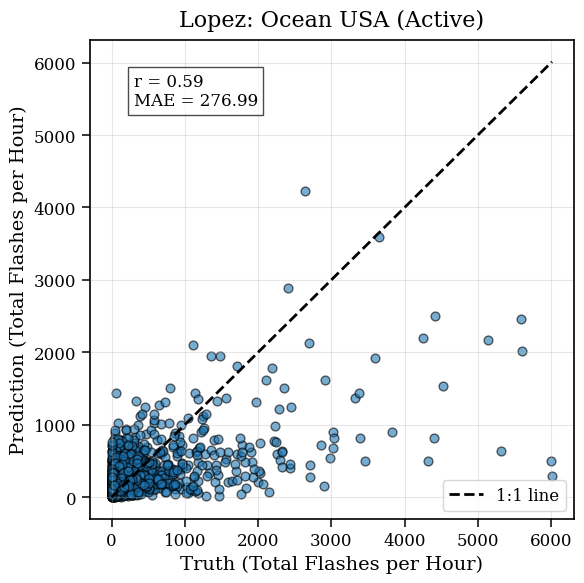

In [20]:
model_idx = 0  # Model 6

# Predictions and truth for ocean
pred_ocean = pred_totals_ocean_ama[model_idx].values
truth_ocean = truth_total_ocean_ama.values

# Flatten arrays to 1D
pred_ocean = pred_ocean.ravel()
truth_ocean = truth_ocean.ravel()

# Check that shapes match
assert pred_ocean.shape == truth_ocean.shape, "Prediction and truth arrays must have the same length!"

# Compute metrics
r = np.corrcoef(truth_ocean, pred_ocean)[0, 1]  # Pearson correlation
mae = np.mean(np.abs(pred_ocean - truth_ocean))  # Mean Absolute Error

# Create figure
plt.figure(figsize=(6,6))
plt.scatter(truth_ocean, pred_ocean, alpha=0.6, color="tab:blue", edgecolor='k', s=40)

# 1:1 reference line
max_val = max(truth_ocean.max(), pred_ocean.max())
plt.plot([0, max_val], [0, max_val], 'k--', label="1:1 line")

# Add text box with metrics
plt.text(
    0.05*max_val, 0.9*max_val,  # position in axes coordinates
    f"r = {r:.2f}\nMAE = {mae:.2f}",
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='k')
)

plt.xlabel("Truth (Total Flashes per Hour)")
plt.ylabel("Prediction (Total Flashes per Hour)")
plt.title("Lopez: Ocean USA (Active)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


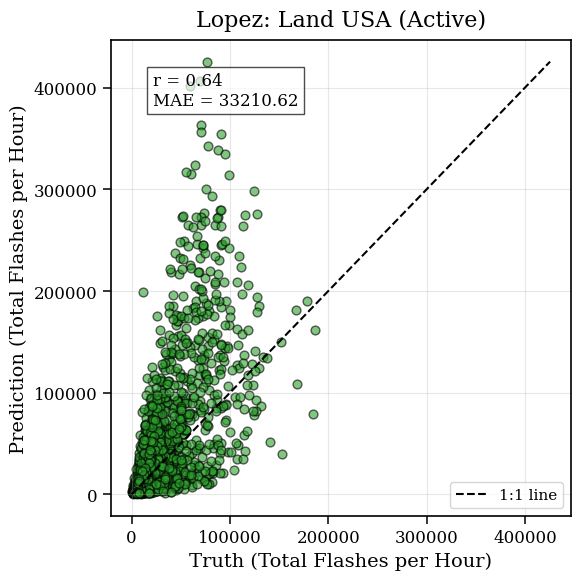

In [63]:
model_idx = 1  # Model 6

# Predictions and truth for ocean
pred_land = pred_totals_land_ama[model_idx].values
truth_land = truth_total_land_ama.values

# Flatten arrays to 1D
pred_land = pred_land.ravel()
truth_land = truth_land.ravel()

# Check that shapes match
assert pred_land.shape == truth_land.shape, "Prediction and truth arrays must have the same length!"

# Compute metrics
r = np.corrcoef(truth_land, pred_land)[0, 1]  # Pearson correlation
mae = np.mean(np.abs(pred_land - truth_land))  # Mean Absolute Error

# Create figure
plt.figure(figsize=(6,6))
plt.scatter(truth_land, pred_land, alpha=0.6, color="tab:green", edgecolor='k', s=40)

# 1:1 reference line
max_val = max(truth_land.max(), pred_land.max())
plt.plot([0, max_val], [0, max_val], 'k--', label="1:1 line")

# Add text box with metrics
plt.text(
    0.05*max_val, 0.9*max_val,  # position in axes coordinates
    f"r = {r:.2f}\nMAE = {mae:.2f}",
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='k')
)

plt.xlabel("Truth (Total Flashes per Hour)")
plt.ylabel("Prediction (Total Flashes per Hour)")
plt.title("Lopez: Land USA (Active)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

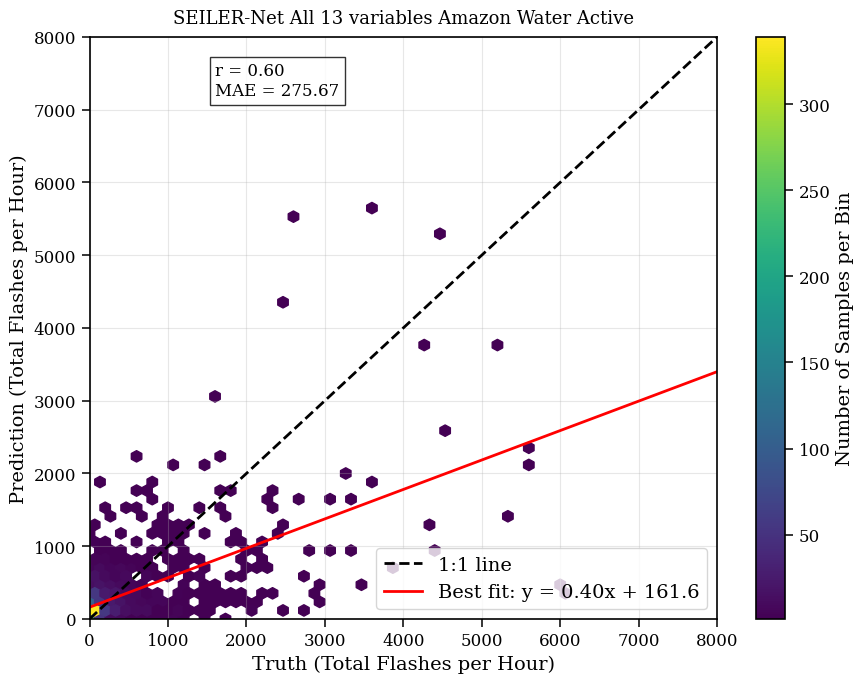

Model R^2 value:  0.3482133746147156


In [153]:
#Hexabin
model_names = ["SEILER-Net", "GEOS-CCM"]

model_idx = 0# Model 6

model = models_JJ[model_idx].astype(np.float32)
model_name = model_names[model_idx]

pred_land = pred_totals_ocean[model_idx].values.ravel()
truth_land = truth_total_ocean.values.ravel()

# Metrics
r = np.corrcoef(truth_land, pred_land)[0, 1]
mae = np.mean(np.abs(pred_land - truth_land))

# --------------------------------------------------
# Define axis limits FIRST
# ------------------------------------------------
xmax = 8000
ymax = 8000
plt.figure(figsize=(9, 7))
plt.xlim(0, xmax)
plt.ylim(0, ymax)

# --------------------------------------------------
# Hexbin with explicit extent
# --------------------------------------------------
hb = plt.hexbin(
    truth_land,
    pred_land,
    gridsize=60,
    mincnt=1,
    cmap="viridis",
    extent=(0, xmax, 0, ymax)   # 🔑 THIS IS THE KEY
)

# 1:1 line
plt.plot([0, xmax], [0, ymax], 'k--', label="1:1 line")

#Best Fit
# Best-fit line (y = m x + b)
m, b = np.polyfit(truth_land, pred_land, 1)

x_line = np.array([0, xmax])
y_fit = m * x_line + b

plt.plot(
    x_line,
    y_fit,
    color="red",
    linewidth=2,
    label=f"Best fit: y = {m:.2f}x + {b:.1f}"
)



# Metrics box
plt.text(
    0.2 * xmax,
    0.9 * ymax,
    f"r = {r:.2f}\nMAE = {mae:.2f}",
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='k')
)

plt.xlabel("Truth (Total Flashes per Hour)")
plt.ylabel("Prediction (Total Flashes per Hour)")
#plt.title("3x3 P = 1.1: Water Amazon (Non-Active)")
plt.title(f"{model_name} Amazon Water Active", fontsize=13)
#ax.set_title(f"{model_name} Land Active", fontsize=13)
plt.grid(alpha=0.3)
# 2. Control the size here
plt.legend(fontsize=14)

# Colorbar
cbar = plt.colorbar(hb)
cbar.set_label("Number of Samples per Bin")

plt.tight_layout()
plt.show()

# R^2 (variance explained)
ss_res = np.sum((truth_land - pred_land)**2)
ss_tot = np.sum((truth_land - np.mean(truth_land))**2)
R2 = 1 - ss_res / ss_tot

print("Model R^2 value: ", R2)


SEILER-Net R^2 value: -0.4393
GEOS Lopez R^2 value: -0.3252


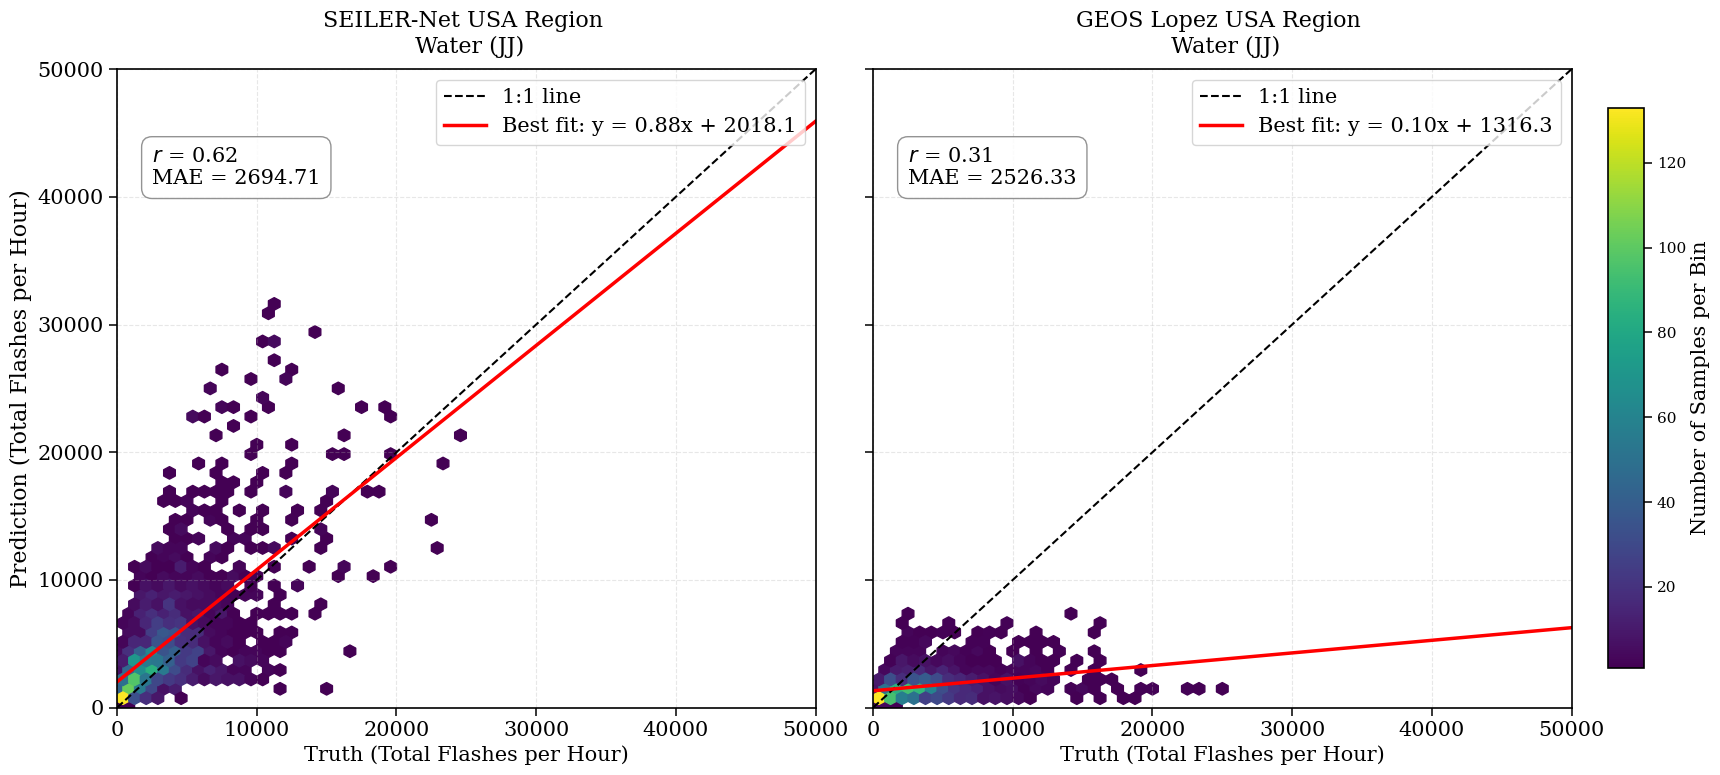

In [18]:
# Setup land/water index mask for the USA
flag = usa_lwi 

land_mask  = flag >= 0.55
water_mask = flag < 0.55

# Define Model Lists for USA (SEILER-Net, GEOS Lopez, GLM)
models_JJ = [RegressionNoPrecip_JJ, lopez_JJ, glm_JJ.squeeze()]

# Apply water mask to isolate ocean datasets
models_ocean_JJ = [m.where(water_mask) for m in models_JJ]

# Calculate hourly spatial sums across the spatial grid
pred_totals_ocean_JJ = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_ocean_JJ]
truth_total_ocean_JJ = glm_JJ.where(water_mask).sum(dim=["Latitudes", "Longitudes"])


# ==========================================
# PART 2: SIDE-BY-SIDE HEXBIN PLOTTING (USA Ocean JJ)
# ==========================================

model_names = ["SEILER-Net", "GEOS Lopez"]
xmax, ymax = 50000, 50000

# Initialize side-by-side figure (sharey=True keeps scales locked for accurate comparison)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
axes = [ax1, ax2]

# The shared ground truth vector
truth_data = truth_total_ocean_JJ.values.ravel()

# Loop through SEILER-Net (idx 0) and GEOS Lopez (idx 1)
for idx, ax in enumerate(axes):
    model_name = model_names[idx]
    pred_data = pred_totals_ocean_JJ[idx].values.ravel()
    
    # Calculate Statistical Performance Metrics
    r = np.corrcoef(truth_data, pred_data)[0, 1]
    mae = np.mean(np.abs(pred_data - truth_data))
    
    ss_res = np.sum((truth_data - pred_data)**2)
    ss_tot = np.sum((truth_data - np.mean(truth_data))**2)
    R2 = 1 - ss_res / ss_tot
    print(f"{model_name} R^2 value: {R2:.4f}")

    # Plot Hexbin Density Map
    hb = ax.hexbin(
        truth_data,
        pred_data,
        gridsize=60,
        mincnt=1,
        cmap="viridis",
        extent=(0, xmax, 0, ymax)
    )
    
    # Draw Reference 1:1 Line
    ax.plot([0, xmax], [0, ymax], 'k--', linewidth=1.5, label="1:1 line")
    
    # Calculate and Plot Linear Regression Line
    m, b = np.polyfit(truth_data, pred_data, 1)
    x_line = np.array([0, xmax])
    y_fit = m * x_line + b
    ax.plot(x_line, y_fit, color="red", linewidth=2.5, label=f"Best fit: y = {m:.2f}x + {b:.1f}")
    
    # Formatting Axes, Grid lines, and Font sizes
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Truth (Total Flashes per Hour)", fontsize=15, fontfamily='serif')
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(loc="upper right", fontsize=15)
    ax.tick_params(axis='both', labelsize=15)
    ax.set_title(f"{model_name} USA Region \n Water (JJ)", fontsize=16, fontfamily='serif', pad=12)
    
    # Text Annotation Box for Statistics
    stats_text = f"$r$ = {r:.2f}\nMAE = {mae:.2f}"
    ax.text(
        0.05 * xmax, 0.82 * ymax, stats_text, 
        fontsize=15, fontfamily='serif',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.5')
    )

# Only add the Y-axis label to the leftmost plot to prevent duplication
ax1.set_ylabel("Prediction (Total Flashes per Hour)", fontsize=16, fontfamily='serif')

# Adjust layout boundaries to make room for a unified colorbar on the right
plt.tight_layout()
fig.subplots_adjust(right=0.88)

# Positioning a single cohesive colorbar for both plots
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70]) # [left, bottom, width, height]
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("Number of Samples per Bin", fontsize=15, fontfamily='serif')
cbar.ax.tick_params(labelsize=11)

# Save vector file and render
#plt.savefig("usa_water_active_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()

SEILER-Net (Active (ON)) R^2 value: 0.4659
GEOS-CCM (Active (ON)) R^2 value: -1.8523
SEILER-Net (Non-Active (JJ)) R^2 value: 0.3683
GEOS-CCM (Non-Active (JJ)) R^2 value: 0.1426


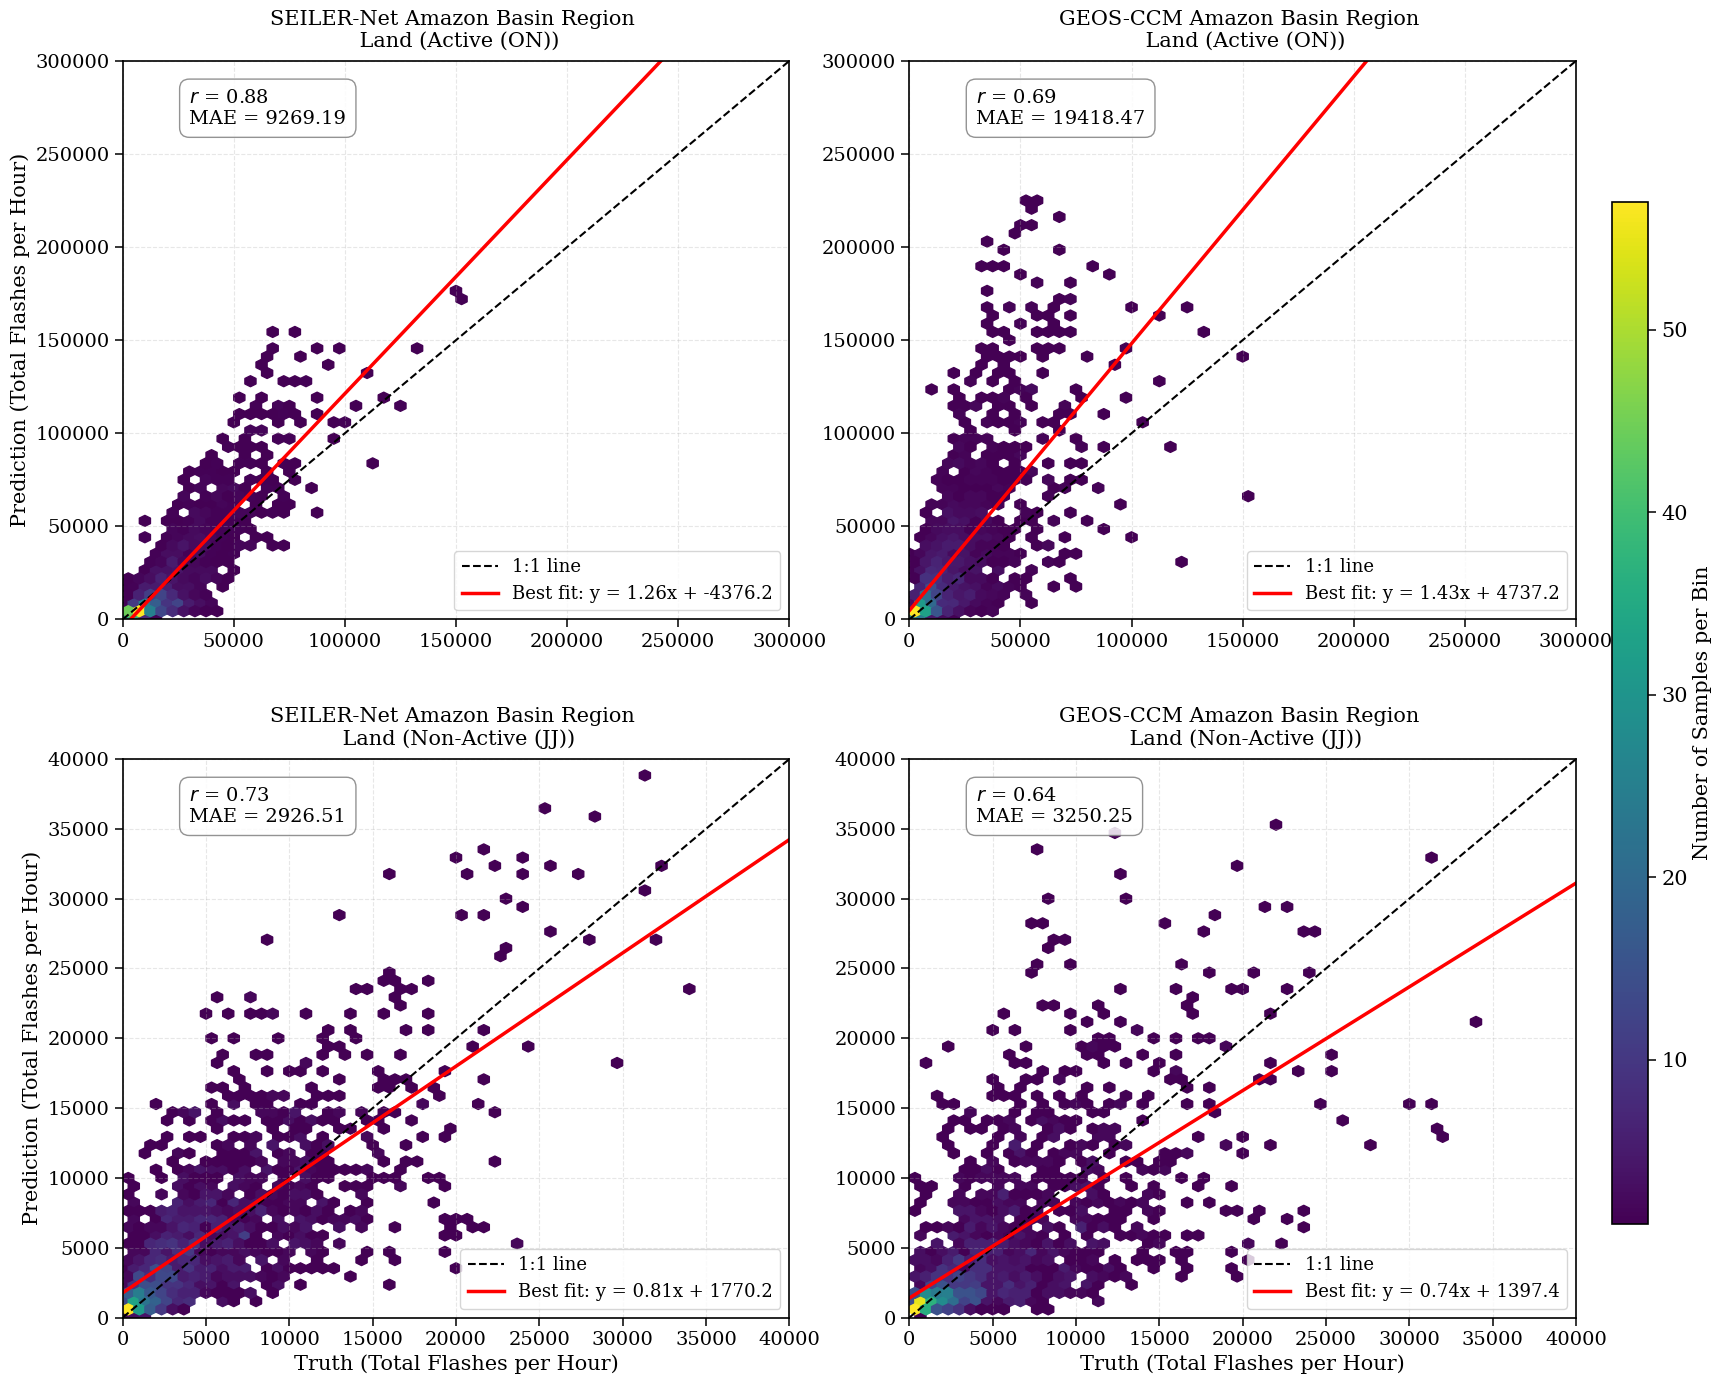

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# PART 1: DATA PREPARATION (Amazon Land - JJ & ON)
# ==========================================

# Setup land/water index mask for the USA
flag = usa_lwi 
land_mask  = flag >= 0.55
water_mask = flag < 0.55

# --- ACTIVE SEASON (ON for Amazon) ---
# Define Model Lists for Amazon (SEILER-Net, GEOS Lopez, GLM)
models_ON_ama = [RegressionNoPrecip_ON_ama, lopez_ON_ama, glm_ON_ama.squeeze()]

# Apply land mask to isolate land datasets
models_land_ON_ama = [m.where(land_mask) for m in models_ON_ama]

# Calculate hourly spatial sums across the spatial grid
pred_totals_land_ON_ama = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_land_ON_ama]
truth_total_land_ON_ama = glm_ON_ama.where(land_mask).sum(dim=["Latitudes", "Longitudes"])


# --- NON-ACTIVE SEASON (JJ for Amazon) ---
# Define Model Lists for Amazon (SEILER-Net, GEOS Lopez, GLM)
models_JJ_ama = [RegressionNoPrecip_JJ_ama, lopez_JJ_ama, glm_JJ_ama.squeeze()]

# Apply land mask to isolate land datasets
models_land_JJ_ama = [m.where(land_mask) for m in models_JJ_ama]

# Calculate hourly spatial sums across the spatial grid
pred_totals_land_JJ_ama = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_land_JJ_ama]
truth_total_land_JJ_ama = glm_JJ_ama.where(land_mask).sum(dim=["Latitudes", "Longitudes"])


# ==========================================
# PART 2: 4-PANEL SIDE-BY-SIDE HEXBIN PLOTTING
# ==========================================

model_names = ["SEILER-Net", "GEOS-CCM"]

# Initialize a 2x2 figure grid without global axis sharing 
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Swapped configurations: Active (ON) is now Row 0, Non-Active (JJ) is now Row 1
seasons_config = [
    {
        "season_label": "Active (ON)", 
        "truth": truth_total_land_ON_ama.values.ravel(), 
        "preds": pred_totals_land_ON_ama,
        "row_idx": 0,
        "xmax": 300000,
        "ymax": 300000
    },
    {
        "season_label": "Non-Active (JJ)", 
        "truth": truth_total_land_JJ_ama.values.ravel(), 
        "preds": pred_totals_land_JJ_ama,
        "row_idx": 1,
        "xmax": 40000,
        "ymax": 40000
    }
]

# Loop through Seasons (Rows) and Models (Columns)
for config in seasons_config:
    row = config["row_idx"]
    season_lbl = config["season_label"]
    truth_data = config["truth"]
    s_xmax = config["xmax"]
    s_ymax = config["ymax"]
    
    for col in range(2):
        ax = axes[row, col]
        model_name = model_names[col]
        pred_data = config["preds"][col].values.ravel()
        
        # Calculate Statistical Performance Metrics
        r = np.corrcoef(truth_data, pred_data)[0, 1]
        mae = np.mean(np.abs(pred_data - truth_data))
        
        ss_res = np.sum((truth_data - pred_data)**2)
        ss_tot = np.sum((truth_data - np.mean(truth_data))**2)
        R2 = 1 - ss_res / ss_tot
        print(f"{model_name} ({season_lbl}) R^2 value: {R2:.4f}")

        # Plot Hexbin Density Map using row-specific limits
        hb = ax.hexbin(
            truth_data,
            pred_data,
            gridsize=60,
            mincnt=1,
            cmap="viridis",
            extent=(0, s_xmax, 0, s_ymax)
        )
        
        # Draw Reference 1:1 Line
        ax.plot([0, s_xmax], [0, s_ymax], 'k--', linewidth=1.5, label="1:1 line")
        
        # Calculate and Plot Linear Regression Line
        m, b = np.polyfit(truth_data, pred_data, 1)
        x_line = np.array([0, s_xmax])
        y_fit = m * x_line + b
        ax.plot(x_line, y_fit, color="red", linewidth=2.5, label=f"Best fit: y = {m:.2f}x + {b:.1f}")
        
        # Formatting Axes and Grid lines dynamically
        ax.set_xlim(0, s_xmax)
        ax.set_ylim(0, s_ymax)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(loc="lower right", fontsize=13)
        ax.tick_params(axis='both', labelsize=14)
        
        # Panel Title dynamically setting Model and Season
        ax.set_title(f"{model_name} Amazon Basin Region \n Land ({season_lbl})", fontsize=15, fontfamily='serif', pad=10)
        
        # Text Annotation Box for Statistics safely tucked under the title
        stats_text = f"$r$ = {r:.2f}\nMAE = {mae:.2f}"
        ax.text(
            0.1, 0.95, stats_text, 
            transform=ax.transAxes,
            verticalalignment='top',
            horizontalalignment='left',
            fontsize=14, fontfamily='serif',
            zorder=5,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.5')
        )

# Only apply X-axis labels to the bottom row of plots to reduce clutter
for ax in axes[1, :]:
    ax.set_xlabel("Truth (Total Flashes per Hour)", fontsize=15, fontfamily='serif')

# Only apply Y-axis labels to the leftmost column of plots to reduce clutter
for ax in axes[:, 0]:
    ax.set_ylabel("Prediction (Total Flashes per Hour)", fontsize=15, fontfamily='serif')

# Clean up spacing and allocate room on the right for the colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.88, hspace=0.25, wspace=0.18)

# Positioning a single cohesive colorbar spanning the height of the 2x2 grid
cbar_ax = fig.add_axes([0.90, 0.12, 0.02, 0.73]) # [left, bottom, width, height]
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("Number of Samples per Bin", fontsize=15, fontfamily='serif')
cbar.ax.tick_params(labelsize=15)

# Save vector file and render
plt.savefig("amazon_land_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()

SEILER-Net (Active (JJ)) R^2 value: -0.4393
GEOS-CCM (Active (JJ)) R^2 value: -0.3252
SEILER-Net (Non-Active (ON)) R^2 value: 0.3231
GEOS-CCM (Non-Active (ON)) R^2 value: 0.1256


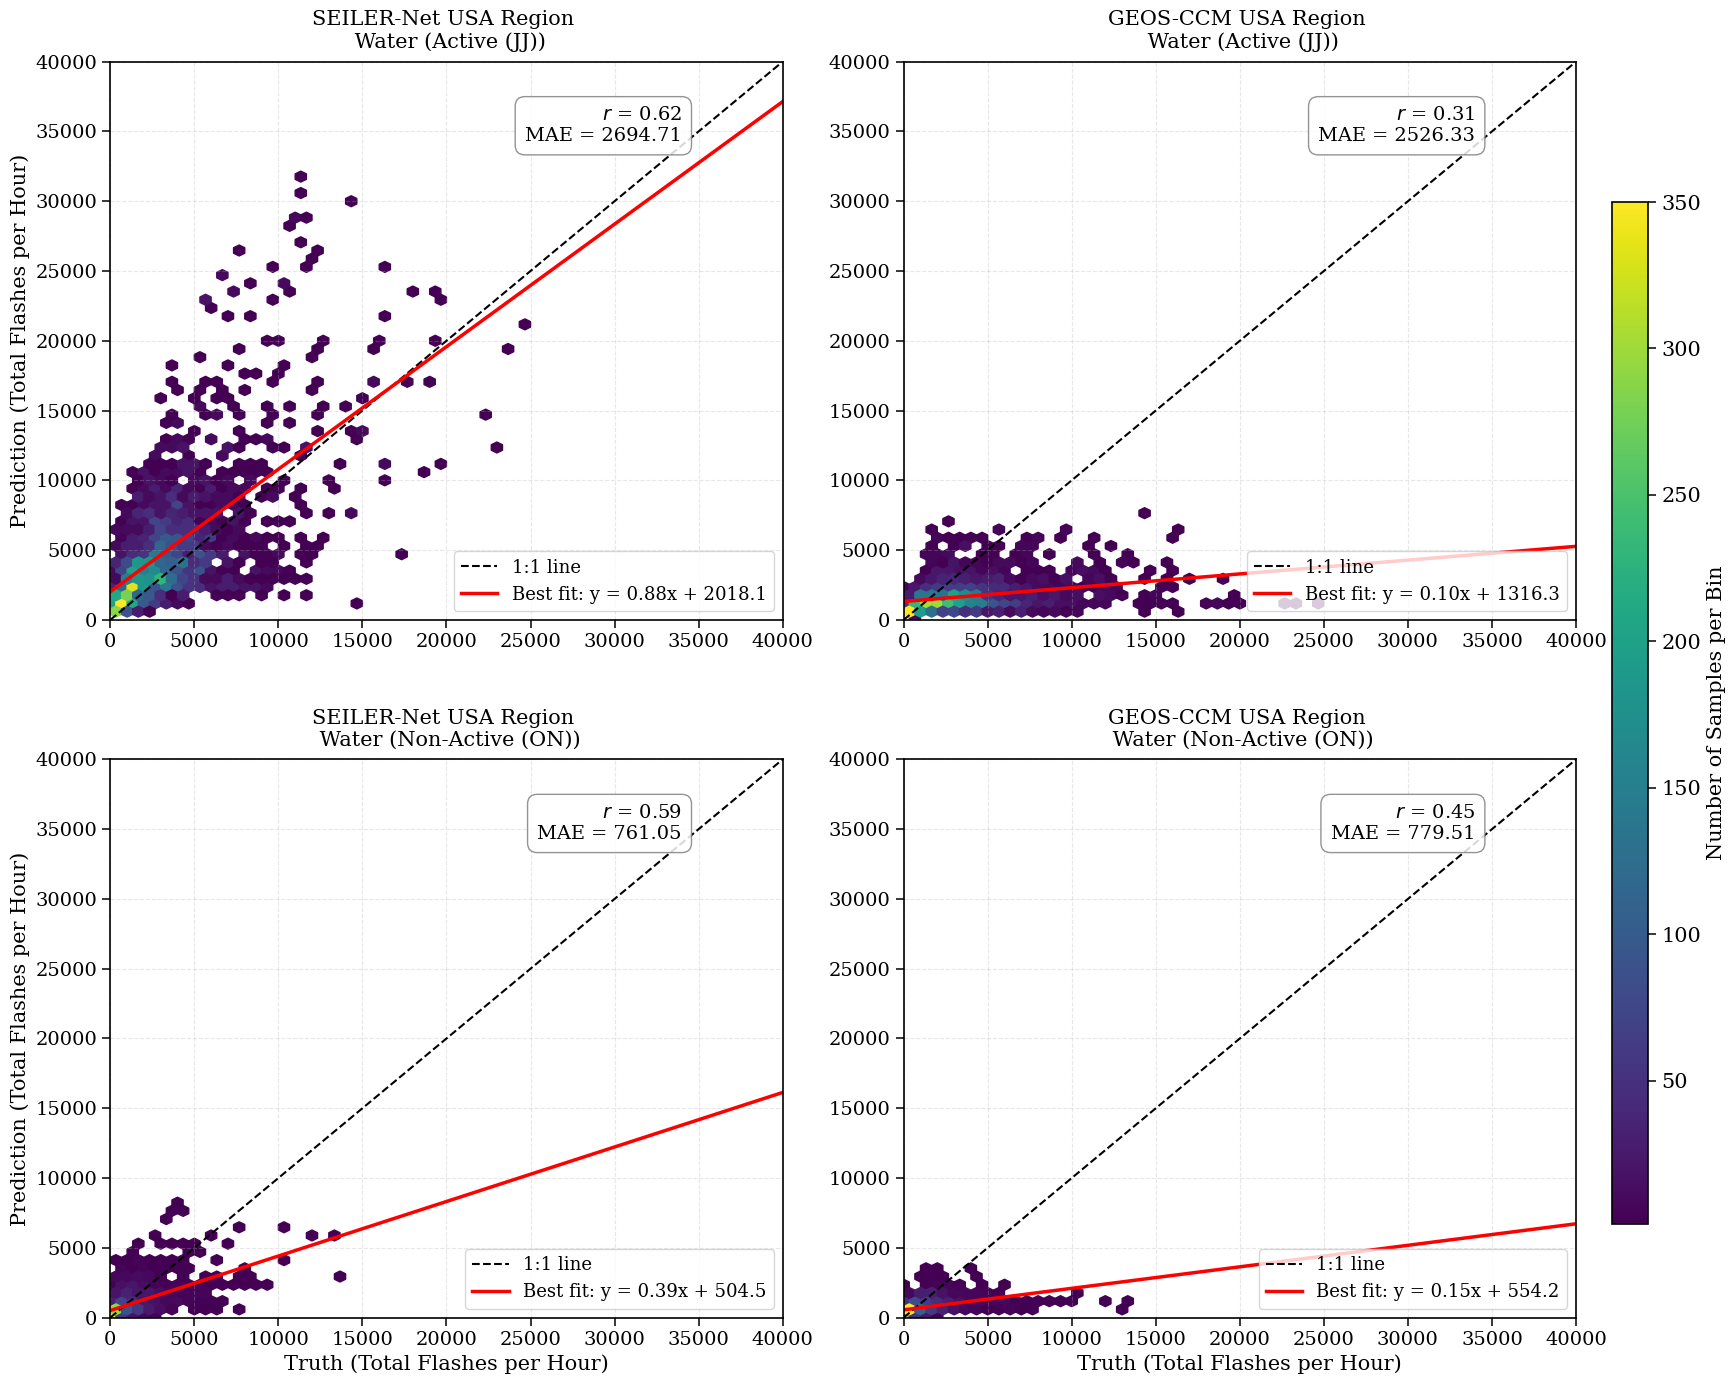

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# PART 1: DATA PREPARATION (USA Land - JJ & ON)
# ==========================================

# Setup land/water index mask for the USA
flag = usa_lwi 
land_mask  = flag >= 0.55
water_mask = flag < 0.55

# --- ACTIVE SEASON (JJ) ---
# Define Model Lists for USA (SEILER-Net, GEOS Lopez, GLM)
models_JJ = [RegressionNoPrecip_JJ, lopez_JJ, glm_JJ.squeeze()]

# Apply land mask to isolate land datasets
models_water_JJ = [m.where(water_mask) for m in models_JJ]

# Calculate hourly spatial sums across the spatial grid
pred_totals_water_JJ = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_water_JJ]
truth_total_water_JJ = glm_JJ.where(water_mask).sum(dim=["Latitudes", "Longitudes"])


# --- NON-ACTIVE SEASON (ON) ---
# Define Model Lists for USA (SEILER-Net, GEOS Lopez, GLM)
models_ON = [RegressionNoPrecip_ON, lopez_ON, glm_ON.squeeze()]

# Apply land mask to isolate land datasets
models_water_ON = [m.where(water_mask) for m in models_ON]

# Calculate hourly spatial sums across the spatial grid
pred_totals_water_ON = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_water_ON]
truth_total_water_ON = glm_ON.where(water_mask).sum(dim=["Latitudes", "Longitudes"])


# ==========================================
# PART 2: 4-PANEL SIDE-BY-SIDE HEXBIN PLOTTING
# ==========================================

model_names = ["SEILER-Net", "GEOS-CCM"]

# Initialize a 2x2 figure grid without global axis sharing 
# (This allows rows to have completely different limits)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Define configuration list with specific xmax/ymax limits for each row
seasons_config = [
    {
        "season_label": "Active (JJ)", 
        "truth": truth_total_water_JJ.values.ravel(), 
        "preds": pred_totals_water_JJ,
        "row_idx": 0,
        "xmax": 40000,
        "ymax": 40000
    },
    {
        "season_label": "Non-Active (ON)", 
        "truth": truth_total_water_ON.values.ravel(), 
        "preds": pred_totals_water_ON,
        "row_idx": 1,
        "xmax": 40000,
        "ymax": 40000
    }
]

# Loop through Seasons (Rows) and Models (Columns)
for config in seasons_config:
    row = config["row_idx"]
    season_lbl = config["season_label"]
    truth_data = config["truth"]
    s_xmax = config["xmax"]
    s_ymax = config["ymax"]
    
    for col in range(2):
        ax = axes[row, col]
        model_name = model_names[col]
        pred_data = config["preds"][col].values.ravel()
        
        # Calculate Statistical Performance Metrics
        r = np.corrcoef(truth_data, pred_data)[0, 1]
        mae = np.mean(np.abs(pred_data - truth_data))
        
        ss_res = np.sum((truth_data - pred_data)**2)
        ss_tot = np.sum((truth_data - np.mean(truth_data))**2)
        R2 = 1 - ss_res / ss_tot
        print(f"{model_name} ({season_lbl}) R^2 value: {R2:.4f}")

        # Plot Hexbin Density Map using row-specific limits
        hb = ax.hexbin(
            truth_data,
            pred_data,
            gridsize=60,
            mincnt=1,
            cmap="viridis",
            extent=(0, s_xmax, 0, s_ymax)
        )
        
        # Draw Reference 1:1 Line
        ax.plot([0, s_xmax], [0, s_ymax], 'k--', linewidth=1.5, label="1:1 line")
        
        # Calculate and Plot Linear Regression Line
        m, b = np.polyfit(truth_data, pred_data, 1)
        x_line = np.array([0, s_xmax])
        y_fit = m * x_line + b
        ax.plot(x_line, y_fit, color="red", linewidth=2.5, label=f"Best fit: y = {m:.2f}x + {b:.1f}")
        
        # Formatting Axes and Grid lines dynamically
        ax.set_xlim(0, s_xmax)
        ax.set_ylim(0, s_ymax)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(loc="lower right", fontsize=13)
        ax.tick_params(axis='both', labelsize=14)
        
        # Panel Title dynamically setting Model and Season
        ax.set_title(f"{model_name} USA Region \n Water ({season_lbl})", fontsize=15, fontfamily='serif', pad=10)
        
       # Text Annotation Box for Statistics (Anchored to Upper Left via transAxes)
        stats_text = f"$r$ = {r:.2f}\nMAE = {mae:.2f}"
        ax.text(
            0.85, 0.92, stats_text, 
            transform=ax.transAxes,
            verticalalignment='top',
            horizontalalignment='right',
            fontsize=14, fontfamily='serif',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.5')
        )

# Only apply X-axis labels to the bottom row of plots to reduce clutter
for ax in axes[1, :]:
    ax.set_xlabel("Truth (Total Flashes per Hour)", fontsize=15, fontfamily='serif')

# Only apply Y-axis labels to the leftmost column of plots to reduce clutter
for ax in axes[:, 0]:
    ax.set_ylabel("Prediction (Total Flashes per Hour)", fontsize=15, fontfamily='serif')

# Clean up spacing and allocate room on the right for the colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.88, hspace=0.25, wspace=0.18)

# Positioning a single cohesive colorbar spanning the height of the 2x2 grid
cbar_ax = fig.add_axes([0.90, 0.12, 0.02, 0.73]) # [left, bottom, width, height]
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("Number of Samples per Bin", fontsize=15, fontfamily='serif')
cbar.ax.tick_params(labelsize=15)

# Save vector file and render
plt.savefig("usa_water_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()